In [2]:
%matplotlib inline

# 🏥 MedTrack — No-Show Prediction Pipeline
### Outpatient Follow-Up Risk Analysis System

> All graphs render inline in the output cell below each section.

---

#### ⚙️ Setup — Imports, File Paths & Global Style

In [ ]:
# ── File paths ────────────────────────────────────────────────────────────────
APPT_FILE = "data/Appointment_Data_Fixed.xlsx"
PAT_FILE = "data/Patient_Data_Fixed.xlsx"
OUTPUT_DIR = "ml/results/"

# ─────────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             precision_score, recall_score, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

import os
os.chdir('/content')

def save(filename):
    plt.savefig(f'/content/{filename}', ...)

#### 🎨 MEDTRACK — GLOBAL GRAPH STYLE

In [4]:
BG     = "#0F1923"
CARD   = "#1A2535"
TEXT   = "#E8EDF2"
SUBTLE = "#6B7A8D"
ACCENT = "#00D4FF"

plt.rcParams.update({
    'figure.facecolor'      : BG,
    'figure.dpi'            : 130,
    'figure.titlesize'      : 18,
    'figure.titleweight'    : 'bold',
    'axes.facecolor'        : CARD,
    'axes.edgecolor'        : '#2A3A50',
    'axes.labelcolor'       : TEXT,
    'axes.labelsize'        : 13,
    'axes.labelweight'      : 'bold',
    'axes.titlesize'        : 14,
    'axes.titleweight'      : 'bold',
    'axes.titlecolor'       : ACCENT,
    'axes.titlepad'         : 10,
    'axes.spines.top'       : False,
    'axes.spines.right'     : False,
    'axes.grid'             : True,
    'axes.grid.axis'        : 'y',
    'grid.color'            : '#1E2D40',
    'grid.alpha'            : 0.5,
    'grid.linewidth'        : 0.6,
    'xtick.color'           : TEXT,
    'ytick.color'           : TEXT,
    'xtick.labelsize'       : 11,
    'ytick.labelsize'       : 11,
    'xtick.major.pad'       : 6,
    'ytick.major.pad'       : 6,
    'legend.facecolor'      : CARD,
    'legend.edgecolor'      : '#2A3A50',
    'legend.labelcolor'     : TEXT,
    'legend.fontsize'       : 11,
    'text.color'            : TEXT,
    'font.size'             : 12,
    'lines.linewidth'       : 2.2,
    'patch.linewidth'       : 0.5,
})

#### 📂 1. LOAD & MERGE

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df_app = pd.read_excel(APPT_FILE)
df_pat = pd.read_excel(PAT_FILE)
df_app.columns = df_app.columns.str.strip()
df_pat.columns = df_pat.columns.str.strip()

pat_cols = ['Patient_ID','Insurance Type','Social Deprivation Index',
            'Residential Pincode','Gender','Age']
df = pd.merge(df_app, df_pat[pat_cols], on='Patient_ID', how='left')
df.columns = df.columns.str.strip()

df["Booking Entry Date"] = pd.to_datetime(df["Booking Entry Date"])
df["Appointment Date"]   = pd.to_datetime(df["Appointment Date"])

print(f"Dataset loaded: {df.shape[0]:,} appointments, {df.shape[1]} columns")
print(f"No-show rate: {df['No Show'].mean():.1%}")

Dataset loaded: 18,302 appointments, 20 columns
No-show rate: 22.9%


#### 🔧 2. FEATURE ENGINEERING (16 features)

In [7]:
def normalize(col):
    r = col.max() - col.min()
    return (col - col.min()) / r if r != 0 else col * 0

# F1:  Waiting days — appointment date minus booking date
df["waiting_days"]      = (df["Appointment Date"] - df["Booking Entry Date"]).dt.days
df["waiting_factor"]    = normalize(df["waiting_days"])

# F2:  Gap since last appointment
df["gap_factor"]        = normalize(df["Time from Last Appointment"])

# F3:  Distance proxy (pincode difference)
df["distance"]          = abs(df["Residential Pincode"].astype(int) - df["Clinic Pincode"].astype(int))
df["distance_factor"]   = normalize(df["distance"])

# F4:  Insurance vulnerability
ins_map = {"Private": 0.0, "Government": 0.5, "None": 1.0}
df["insurance_factor"]  = df["Insurance Type"].map(ins_map).fillna(0.5)

# F5:  Social stress index
soc_map = {"Ultra Rich":0.1,"Rich":0.3,"Middle Class":0.5,"Poor":0.8,"Very Poor":1.0}
df["social_factor"]     = df["Social Deprivation Index"].map(soc_map).fillna(0.5)

# F6:  No-show momentum (historical no-show rate)
df["no_show_momentum"]  = df["Previous No Show"] / (df["Previous Visits"] + 1)
df["no_show_momentum"]  = normalize(df["no_show_momentum"])

# F7:  Age factor
df["age_factor"]        = normalize(df["Age"])

# F8:  Gender encoding
df["gender_encoded"]    = (df["Gender"] == "Male").astype(int)

# F9:  Appointment time encoding
time_map = {"Morning": 0, "Afternoon": 1, "Night": 2}
df["time_encoded"]      = df["Appointment Time"].map(time_map).fillna(1)

# F10: Specialty encoding
spec_map = {"Primary Care":0,"Internal Medicine Sub Specialty":1,
            "Other Non-Surgical Sub Specialty":2,"Surgical Specialty":3}
df["specialty_encoded"] = df["Encounter Specialty"].map(spec_map).fillna(0)

# F11: Visit burden
df["visit_burden"]      = df["Expected No.of Visits"] / (df["Total No.of Appointments"] + 1)
df["visit_burden"]      = normalize(df["visit_burden"])

# F12: Appointment month (seasonality)
df["month_factor"]      = normalize(df["Appointment Month"])

# Risk score (weighted sum — used for rule-based prediction)
df["risk_score"] = (
    0.20 * df["waiting_factor"]   +
    0.20 * df["gap_factor"]       +
    0.15 * df["distance_factor"]  +
    0.10 * df["insurance_factor"] +
    0.15 * df["social_factor"]    +
    0.20 * df["no_show_momentum"]
)

FEATURES = [
    "waiting_days","gap_factor","distance_factor","insurance_factor",
    "social_factor","no_show_momentum","age_factor","gender_encoded",
    "time_encoded","specialty_encoded","visit_burden","month_factor",
    "Previous Visits","Previous No Show","Lead Time Days","Expected No.of Visits"
]
FEATURE_LABELS = [
    "Waiting Days","Gap Since Last Visit","Distance Factor","Insurance Vulnerability",
    "Social Stress","No-Show Momentum","Age Factor","Gender","Appointment Time",
    "Specialty","Visit Burden","Appointment Month",
    "Previous Visits","Previous No-Shows","Lead Time Days","Expected Visits"
]
TARGET = "No Show"

print("\nFeatures engineered:")
for i, f in enumerate(FEATURE_LABELS, 1):
    print(f"  F{i:02d}: {f}")


Features engineered:
  F01: Waiting Days
  F02: Gap Since Last Visit
  F03: Distance Factor
  F04: Insurance Vulnerability
  F05: Social Stress
  F06: No-Show Momentum
  F07: Age Factor
  F08: Gender
  F09: Appointment Time
  F10: Specialty
  F11: Visit Burden
  F12: Appointment Month
  F13: Previous Visits
  F14: Previous No-Shows
  F15: Lead Time Days
  F16: Expected Visits


#### ✂️ 3. TRAIN / TEST SPLIT

In [8]:
X = df[FEATURES].fillna(0)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 14,641  |  Test: 3,661


#### 🤖 4. TRAIN MODELS

In [9]:
models = {
    "XGBoost":             GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.1, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nTraining models...")
for name, model in models.items():
    Xtr = X_train_s if name == "Logistic Regression" else X_train
    Xte = X_test_s  if name == "Logistic Regression" else X_test
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:,1]
    roc_auc  = roc_auc_score(y_test, y_proba)
    pr_auc   = average_precision_score(y_test, y_proba)
    sens     = recall_score(y_test, y_pred)
    ppv      = precision_score(y_test, y_pred, zero_division=0)
    cm       = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
    Xcv = X_train_s if name == "Logistic Regression" else X_train
    cv_roc = cross_val_score(model, Xcv, y_train, cv=cv, scoring='roc_auc').mean()
    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "roc_auc": roc_auc, "pr_auc": pr_auc,
        "sensitivity": sens, "ppv": ppv, "cm": cm,
        "fpr": fpr, "tpr": tpr, "prec_c": prec_c, "rec_c": rec_c,
        "cv_roc": cv_roc
    }
    print(f"  {name}: ROC={roc_auc:.3f}  PR={pr_auc:.3f}  Sens={sens:.3f}  PPV={ppv:.3f}")


Training models...
  XGBoost: ROC=0.567  PR=0.279  Sens=0.023  PPV=0.333
  Random Forest: ROC=0.579  PR=0.291  Sens=0.405  PPV=0.291
  Logistic Regression: ROC=0.581  PR=0.294  Sens=0.493  PPV=0.280


#### 🎨 SHARED PLOT STYLE

In [10]:
PALETTE = {
    "XGBoost":             "#E84545",
    "Random Forest":       "#2196F3",
    "Logistic Regression": "#4CAF50"
}

def card_bg(ax):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2A3A50')

def save(name):
    path = os.path.join(OUTPUT_DIR, name)
    plt.savefig(path, dpi=120, bbox_inches='tight', facecolor=BG, edgecolor='none')
    plt.show()
    print(f"  Saved -> {path}")
    plt.close()

#### 📊 GRAPH 1: FEATURE ENGINEERING PIPELINE


[1/9] Generating Feature Engineering Pipeline...


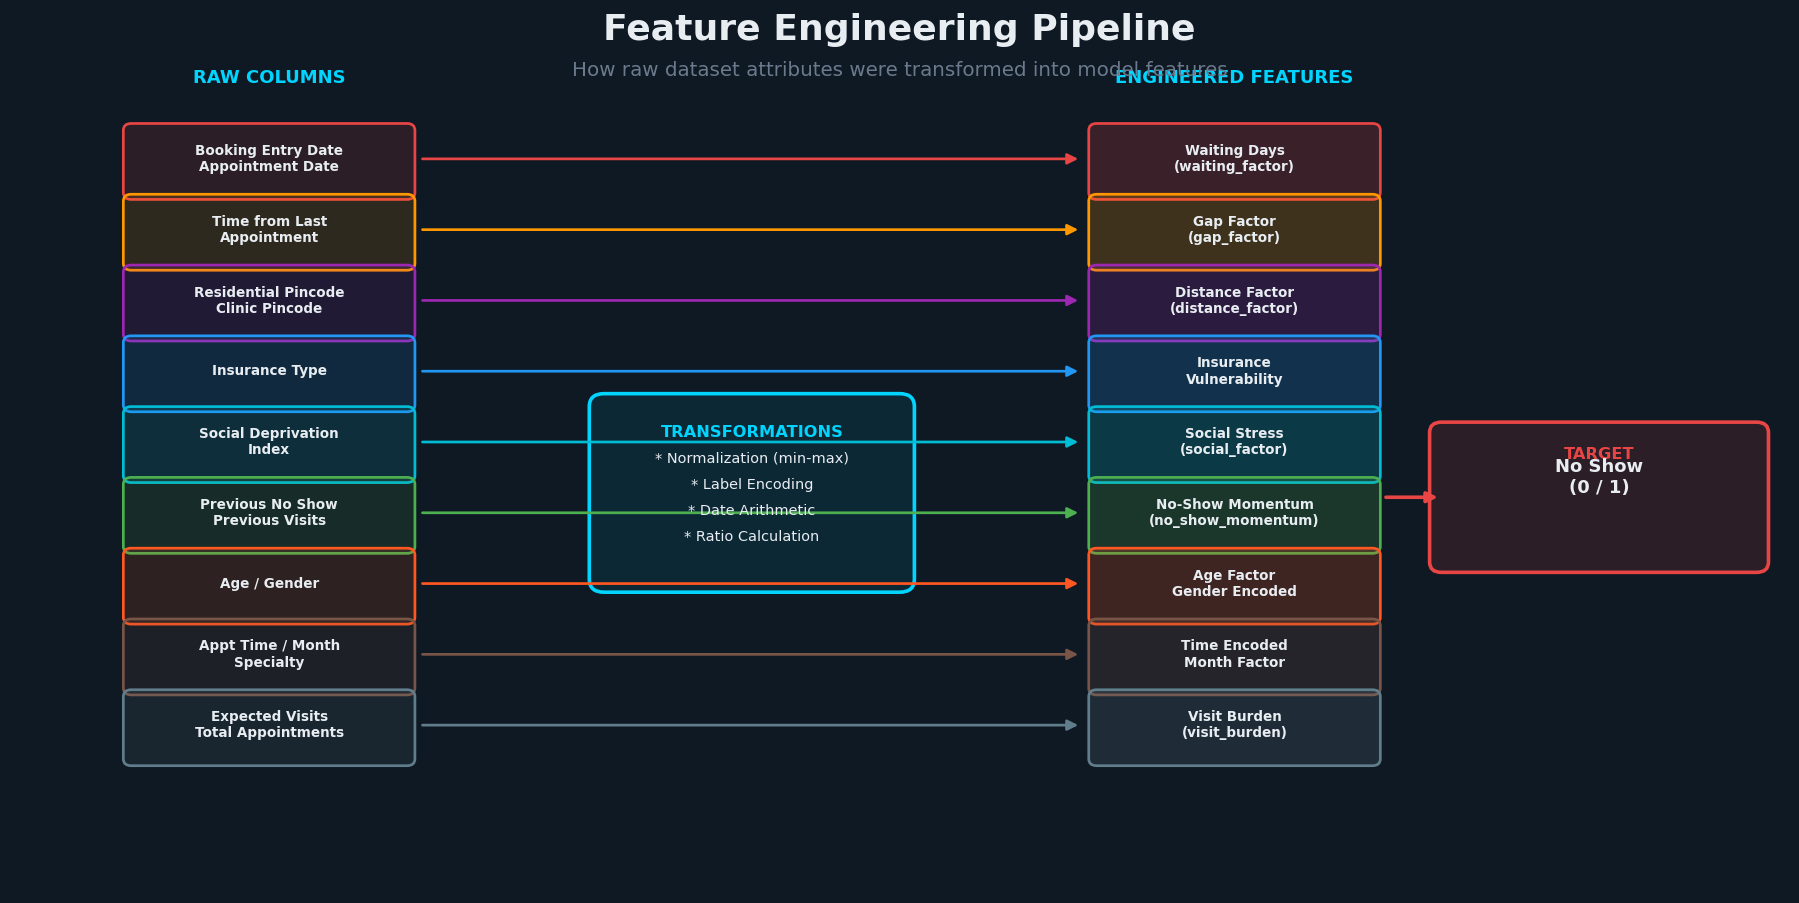

  Saved -> /content/graph1_feature_pipeline.png


In [11]:
print("\n[1/9] Generating Feature Engineering Pipeline...")
fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
ax.set_xlim(0, 18); ax.set_ylim(0, 10); ax.axis('off')
fig.text(0.5, 0.96, "Feature Engineering Pipeline", ha='center',
         fontsize=20, fontweight='bold', color=TEXT)
fig.text(0.5, 0.92, "How raw dataset attributes were transformed into model features",
         ha='center', fontsize=11, color=SUBTLE)

raw_cols = [
    ("Booking Entry Date\nAppointment Date", "#E84545"),
    ("Time from Last\nAppointment", "#FF9800"),
    ("Residential Pincode\nClinic Pincode", "#9C27B0"),
    ("Insurance Type", "#2196F3"),
    ("Social Deprivation\nIndex", "#00BCD4"),
    ("Previous No Show\nPrevious Visits", "#4CAF50"),
    ("Age / Gender", "#FF5722"),
    ("Appt Time / Month\nSpecialty", "#795548"),
    ("Expected Visits\nTotal Appointments", "#607D8B"),
]
feat_cols = [
    ("Waiting Days\n(waiting_factor)", "#E84545"),
    ("Gap Factor\n(gap_factor)", "#FF9800"),
    ("Distance Factor\n(distance_factor)", "#9C27B0"),
    ("Insurance\nVulnerability", "#2196F3"),
    ("Social Stress\n(social_factor)", "#00BCD4"),
    ("No-Show Momentum\n(no_show_momentum)", "#4CAF50"),
    ("Age Factor\nGender Encoded", "#FF5722"),
    ("Time Encoded\nMonth Factor", "#795548"),
    ("Visit Burden\n(visit_burden)", "#607D8B"),
]

raw_x, feat_x = 1.2, 11.0
box_w, box_h = 2.8, 0.72
gap = 0.82
start_y = 8.4

for i, ((label, color), (flabel, fcolor)) in enumerate(zip(raw_cols, feat_cols)):
    y_pos = start_y - i * gap
    rx = FancyBboxPatch((raw_x, y_pos-0.32), box_w, box_h,
                         boxstyle="round,pad=0.08", linewidth=1.5,
                         edgecolor=color, facecolor=color+"22")
    ax.add_patch(rx)
    ax.text(raw_x+box_w/2, y_pos+0.07, label, ha='center', va='center',
            fontsize=7.5, color=TEXT, fontweight='bold')
    ax.annotate("", xy=(feat_x-0.15, y_pos+0.07), xytext=(raw_x+box_w+0.12, y_pos+0.07),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.5))
    fx = FancyBboxPatch((feat_x, y_pos-0.32), box_w, box_h,
                         boxstyle="round,pad=0.08", linewidth=1.5,
                         edgecolor=fcolor, facecolor=fcolor+"33")
    ax.add_patch(fx)
    ax.text(feat_x+box_w/2, y_pos+0.07, flabel, ha='center', va='center',
            fontsize=7.5, color=TEXT, fontweight='bold')

mid_x = (raw_x+box_w+feat_x)/2
tb = FancyBboxPatch((mid_x-1.5, 3.6), 3.0, 2.0, boxstyle="round,pad=0.15",
                     linewidth=2, edgecolor=ACCENT, facecolor=ACCENT+"15")
ax.add_patch(tb)
ax.text(mid_x, 5.25, "TRANSFORMATIONS", ha='center', fontsize=9,
        color=ACCENT, fontweight='bold')
for j, op in enumerate(["* Normalization (min-max)","* Label Encoding",
                          "* Date Arithmetic","* Ratio Calculation"]):
    ax.text(mid_x, 4.95-j*0.3, op, ha='center', fontsize=8, color=TEXT)

tb2 = FancyBboxPatch((14.5, 3.8), 3.2, 1.5, boxstyle="round,pad=0.12",
                      linewidth=2, edgecolor="#E84545", facecolor="#E8454522")
ax.add_patch(tb2)
ax.text(16.1, 5.0, "TARGET", ha='center', fontsize=9, color="#E84545", fontweight='bold')
ax.text(16.1, 4.6, "No Show\n(0 / 1)", ha='center', fontsize=10, color=TEXT, fontweight='bold')
ax.annotate("", xy=(14.5, 4.55), xytext=(feat_x+box_w+0.1, 4.55),
            arrowprops=dict(arrowstyle="-|>", color="#E84545", lw=2.0))
ax.text(raw_x+box_w/2, 9.35, "RAW COLUMNS", ha='center', fontsize=10,
        color=ACCENT, fontweight='bold')
ax.text(feat_x+box_w/2, 9.35, "ENGINEERED FEATURES", ha='center', fontsize=10,
        color=ACCENT, fontweight='bold')
plt.tight_layout()
save('graph1_feature_pipeline.png')

#### 📊 GRAPH 2: CONFUSION MATRICES

[2/9] Generating Confusion Matrices...


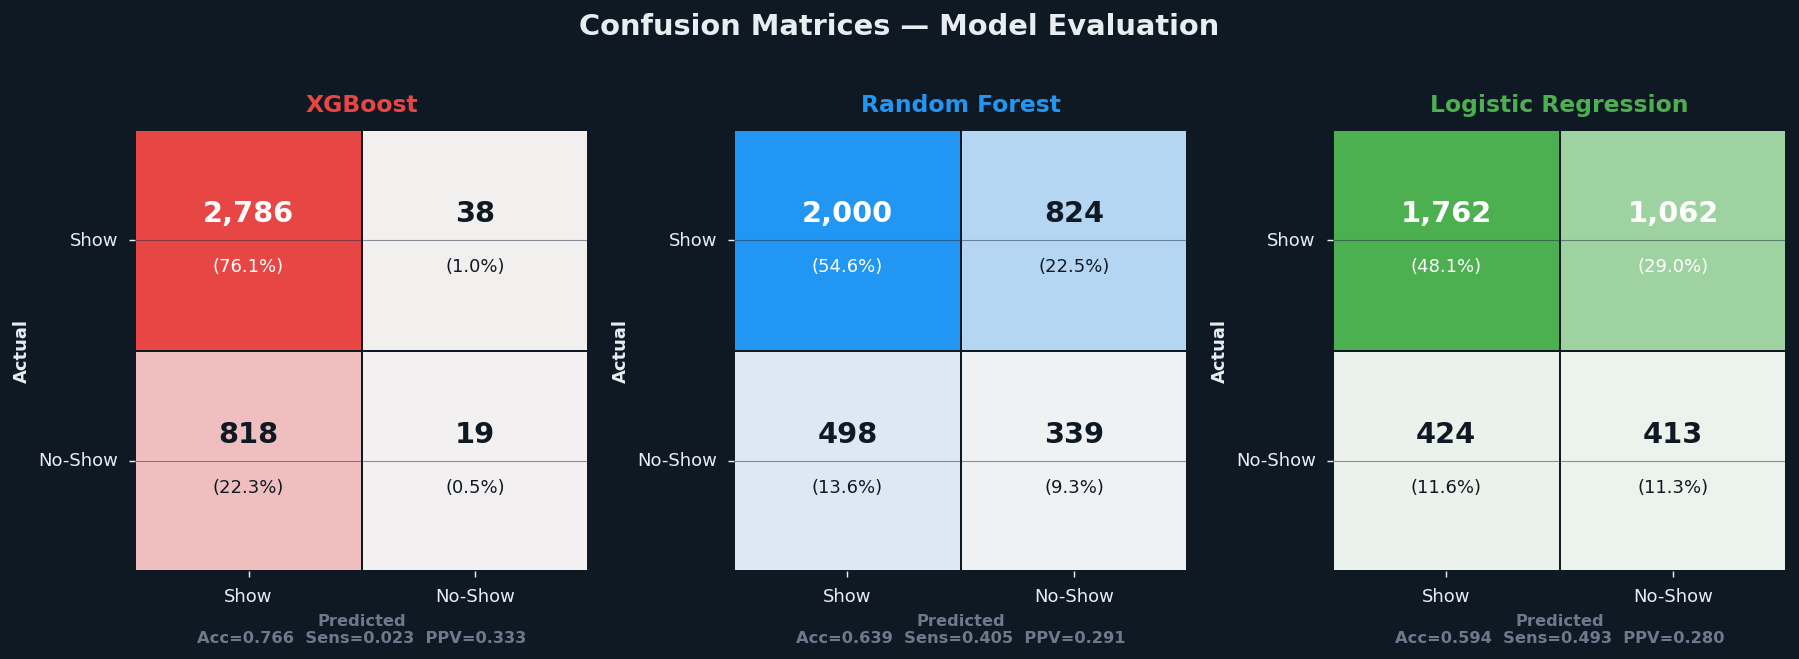

  Saved -> /content/graph2_confusion_matrices.png


In [12]:
print("[2/9] Generating Confusion Matrices...")
fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor=BG)
fig.suptitle("Confusion Matrices — Model Evaluation", fontsize=16,
             fontweight='bold', color=TEXT, y=1.01)
for ax, (name, res) in zip(axes, results.items()):
    cm = res["cm"]
    total = cm.sum()
    cmap = sns.light_palette(PALETTE[name], as_cmap=True)
    sns.heatmap(cm, annot=False, cmap=cmap, ax=ax,
                linewidths=1, linecolor=BG, cbar=False)
    for i in range(2):
        for j in range(2):
            pct = cm[i,j]/total*100
            dark = cm[i,j] > cm.max()*0.5
            ax.text(j+0.5, i+0.38, f"{cm[i,j]:,}", ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white' if dark else BG)
            ax.text(j+0.5, i+0.62, f"({pct:.1f}%)", ha='center', va='center',
                    fontsize=10, color='white' if dark else BG)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(name, fontsize=13, fontweight='bold', color=PALETTE[name], pad=10)
    ax.set_xticklabels(["Show","No-Show"], color=TEXT, fontsize=10)
    ax.set_yticklabels(["Show","No-Show"], color=TEXT, fontsize=10, rotation=0)
    ax.set_xlabel(f"Predicted\nAcc={(tn+tp)/total:.3f}  Sens={res['sensitivity']:.3f}  PPV={res['ppv']:.3f}",
                  fontsize=9, color=SUBTLE)
    ax.set_ylabel("Actual", fontsize=10, color=TEXT)
    ax.set_facecolor(CARD)
plt.tight_layout()
save('graph2_confusion_matrices.png')

#### 📈 GRAPH 3: ROC CURVES

[3/9] Generating ROC Curves...


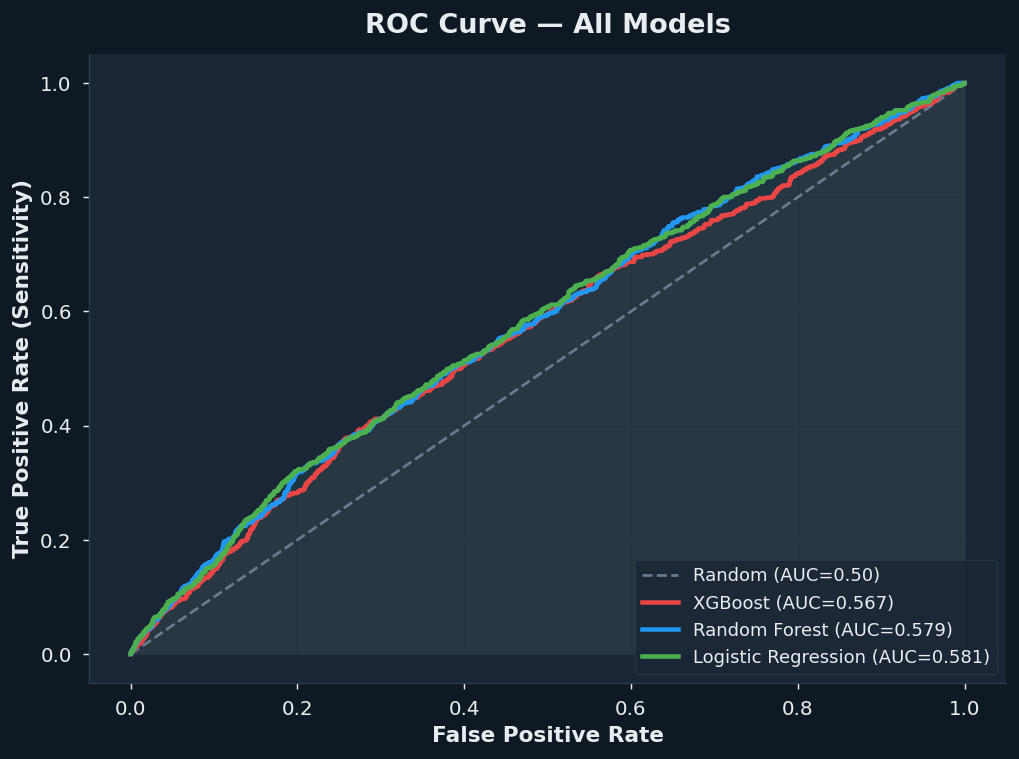

  Saved -> /content/graph3_roc_curves.png


In [13]:
print("[3/9] Generating ROC Curves...")
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
card_bg(ax)
ax.plot([0,1],[0,1],'--', color=SUBTLE, lw=1.5, label='Random (AUC=0.50)')
for name, res in results.items():
    ax.plot(res["fpr"], res["tpr"], lw=2.5, color=PALETTE[name],
            label=f'{name} (AUC={res["roc_auc"]:.3f})')
    ax.fill_between(res["fpr"], res["tpr"], alpha=0.07, color=PALETTE[name])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("ROC Curve — All Models", fontsize=15, fontweight='bold', color=TEXT, pad=12)
ax.legend(loc='lower right', fontsize=10, facecolor=CARD, edgecolor='#2A3A50', labelcolor=TEXT)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save('graph3_roc_curves.png')

#### 📉 GRAPH 4: PRECISION-RECALL CURVES

[4/9] Generating Precision-Recall Curves...


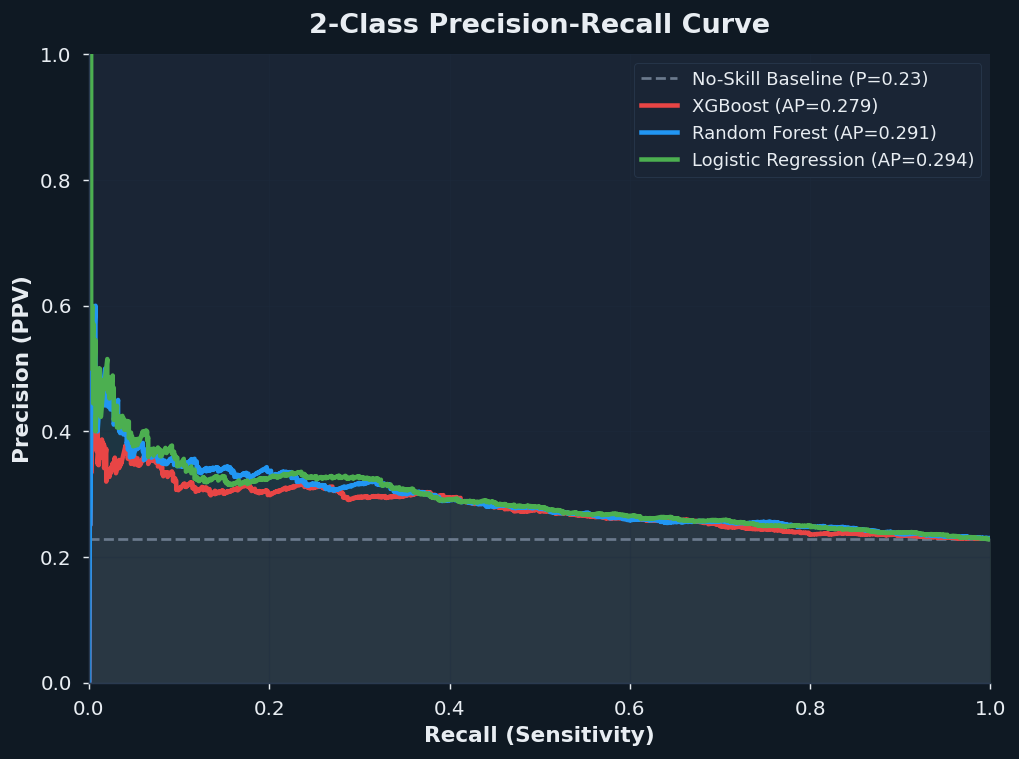

  Saved -> /content/graph4_pr_curves.png


In [14]:
print("[4/9] Generating Precision-Recall Curves...")
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
card_bg(ax)
baseline = y_test.mean()
ax.axhline(y=baseline, color=SUBTLE, linestyle='--', lw=1.5,
           label=f'No-Skill Baseline (P={baseline:.2f})')
for name, res in results.items():
    ax.plot(res["rec_c"], res["prec_c"], lw=2.5, color=PALETTE[name],
            label=f'{name} (AP={res["pr_auc"]:.3f})')
    ax.fill_between(res["rec_c"], res["prec_c"], alpha=0.07, color=PALETTE[name])
ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
ax.set_ylabel("Precision (PPV)", fontsize=12)
ax.set_title("2-Class Precision-Recall Curve", fontsize=15, fontweight='bold', color=TEXT, pad=12)
ax.legend(loc='upper right', fontsize=10, facecolor=CARD, edgecolor='#2A3A50', labelcolor=TEXT)
ax.grid(True, alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
save('graph4_pr_curves.png')

#### 📋 GRAPH 5: PERFORMANCE TABLE

[5/9] Generating Performance Table...


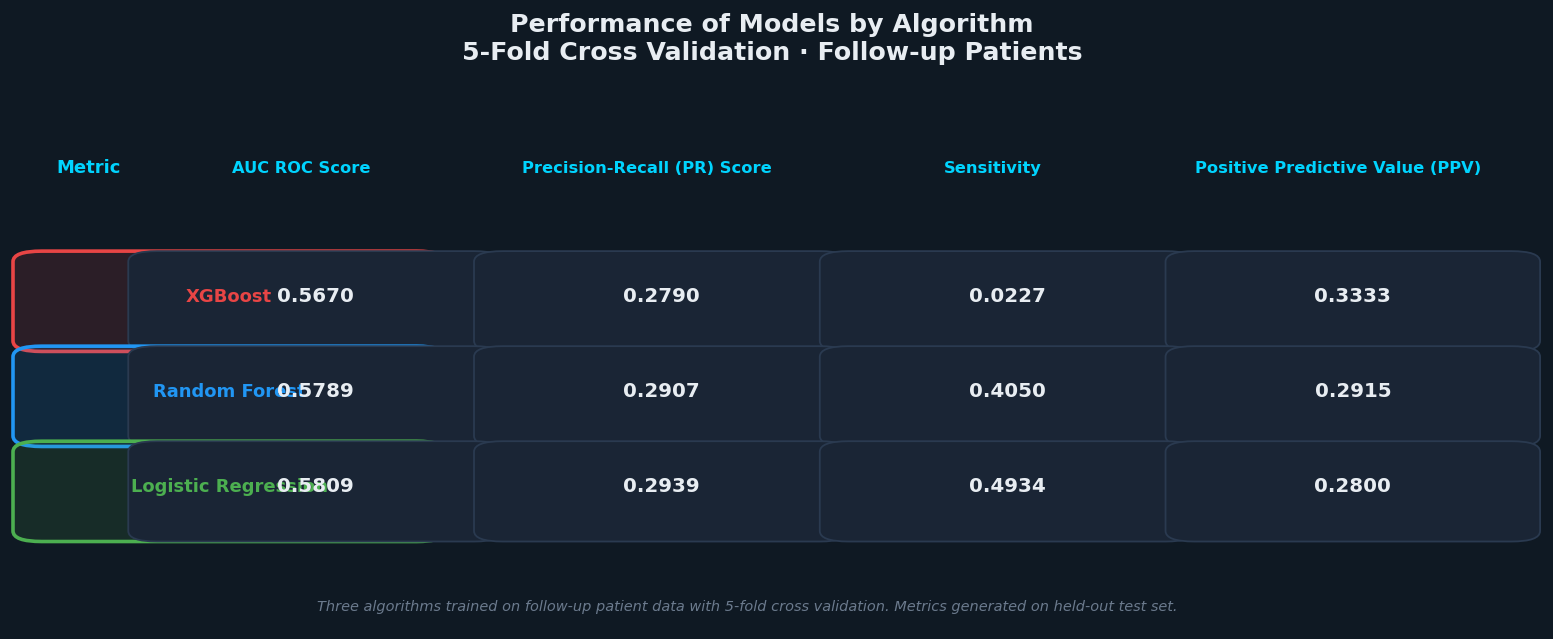

  Saved -> /content/graph5_performance_table.png


In [15]:
print("[5/9] Generating Performance Table...")
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(BG); ax.axis('off')
fig.suptitle("Performance of Models by Algorithm\n5-Fold Cross Validation · Follow-up Patients",
             fontsize=14, fontweight='bold', color=TEXT, y=0.98)

metrics    = ["AUC ROC Score","Precision-Recall (PR) Score","Sensitivity","Positive Predictive Value (PPV)"]
col_xs     = [0.08, 0.32, 0.56, 0.80]
header_y   = 0.78
row_ys     = [0.60, 0.42, 0.24]
cell_w, cell_h = 0.22, 0.15

ax.text(0.02, header_y+0.08, "Metric", transform=ax.transAxes,
        fontsize=10, fontweight='bold', color=ACCENT)
for xi, met in zip(col_xs, metrics):
    ax.text(xi+cell_w/2, header_y+0.08, met, transform=ax.transAxes,
            ha='center', fontsize=9, fontweight='bold', color=ACCENT)

for yi, (name, res) in zip(row_ys, results.items()):
    color = PALETTE[name]
    ml = FancyBboxPatch((0.01, yi-0.06), 0.26, cell_h, transform=ax.transAxes,
                         boxstyle="round,pad=0.02", linewidth=2,
                         edgecolor=color, facecolor=color+"22", clip_on=False)
    ax.add_patch(ml)
    ax.text(0.14, yi+0.015, name, transform=ax.transAxes,
            ha='center', fontsize=10, fontweight='bold', color=color)
    vals = [f"{res['roc_auc']:.4f}", f"{res['pr_auc']:.4f}",
            f"{res['sensitivity']:.4f}", f"{res['ppv']:.4f}"]
    for xi, val in zip(col_xs, vals):
        cb = FancyBboxPatch((xi+0.01, yi-0.06), cell_w, cell_h,
                             transform=ax.transAxes, boxstyle="round,pad=0.02",
                             linewidth=1, edgecolor='#2A3A50', facecolor=CARD, clip_on=False)
        ax.add_patch(cb)
        ax.text(xi+cell_w/2+0.01, yi+0.015, val, transform=ax.transAxes,
                ha='center', fontsize=11, fontweight='bold', color=TEXT)

ax.text(0.5, 0.03,
        "Three algorithms trained on follow-up patient data with 5-fold cross validation. "
        "Metrics generated on held-out test set.",
        transform=ax.transAxes, ha='center', fontsize=8, color=SUBTLE, style='italic')
plt.tight_layout()
save('graph5_performance_table.png')

#### 🔍 GRAPH 6: FEATURE IMPORTANCE

[6/9] Generating Feature Importance...


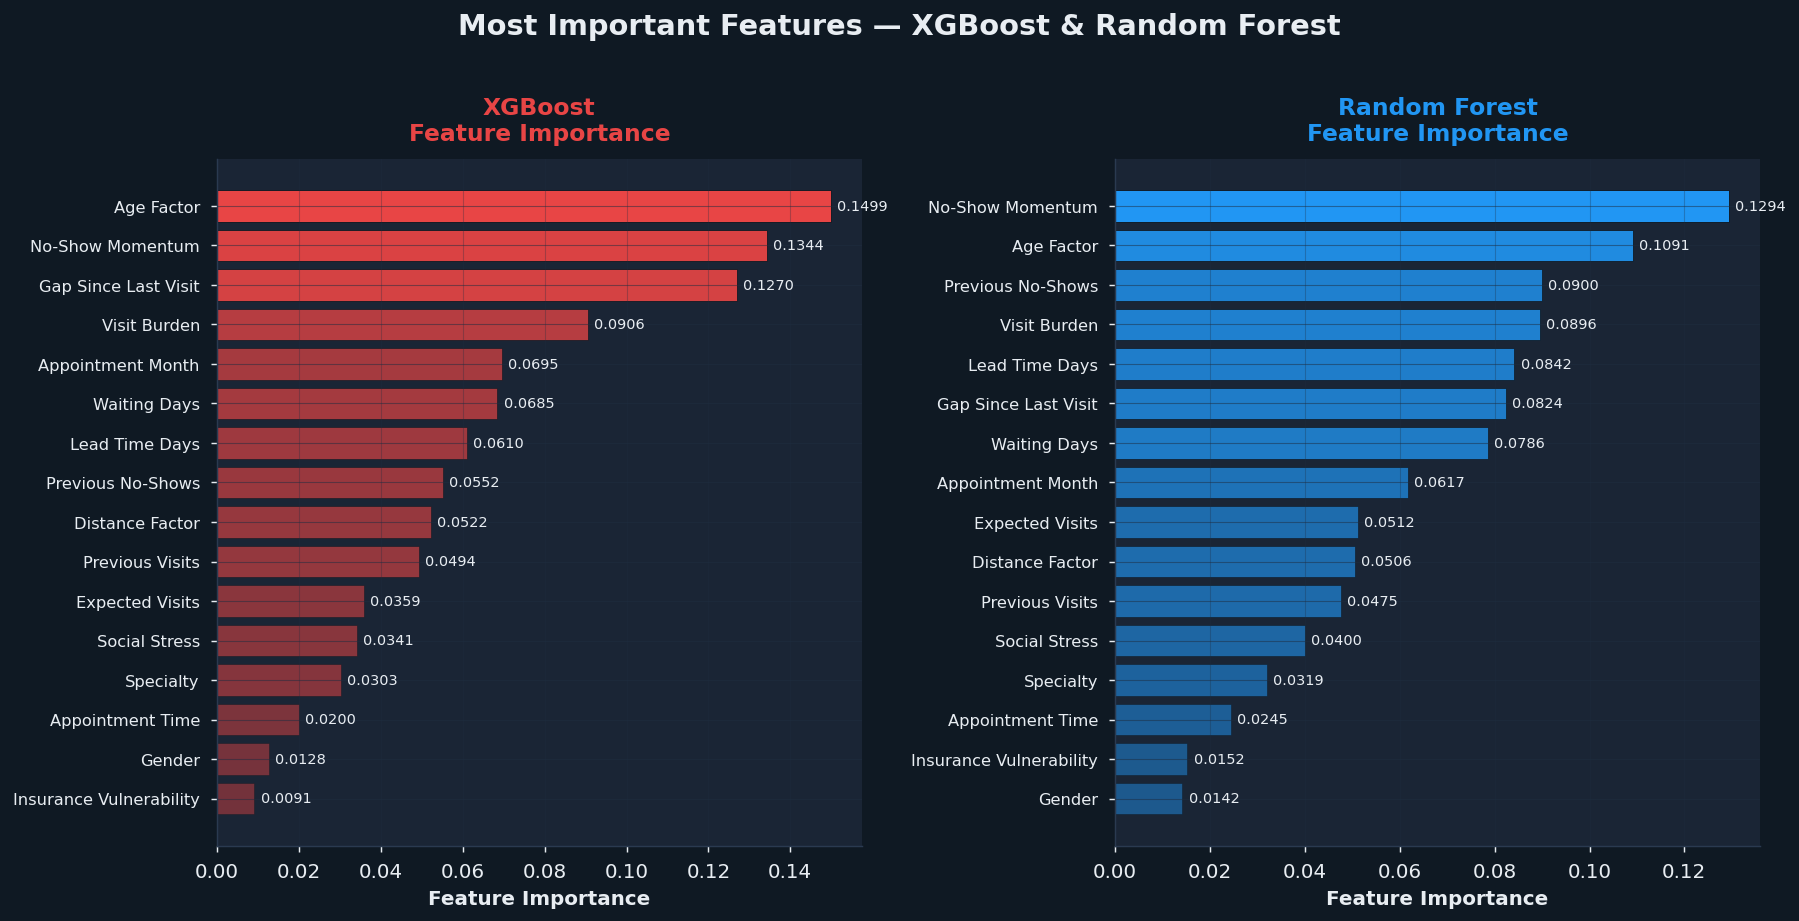

  Saved -> /content/graph6_feature_importance.png


In [16]:
print("[6/9] Generating Feature Importance...")
xgb_imp = pd.Series(results["XGBoost"]["model"].feature_importances_,
                     index=FEATURE_LABELS).sort_values(ascending=True)
rf_imp  = pd.Series(results["Random Forest"]["model"].feature_importances_,
                     index=FEATURE_LABELS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor=BG)
fig.suptitle("Most Important Features — XGBoost & Random Forest",
             fontsize=16, fontweight='bold', color=TEXT, y=1.01)
for ax, (imp, name, color) in zip(axes, [
    (xgb_imp, "XGBoost",      PALETTE["XGBoost"]),
    (rf_imp,  "Random Forest", PALETTE["Random Forest"])
]):
    card_bg(ax)
    bars = ax.barh(range(len(imp)), imp.values, color=color,
                   alpha=0.85, edgecolor=BG, linewidth=0.5)
    max_val = imp.values.max()
    for bar, val in zip(bars, imp.values):
        bar.set_alpha(0.4 + 0.6*(val/max_val))
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=9, color=TEXT)
    ax.set_xlabel("Feature Importance", fontsize=11, color=TEXT)
    ax.set_title(f"{name}\nFeature Importance", fontsize=13,
                 fontweight='bold', color=color, pad=10)
    ax.grid(axis='x', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, imp.values)):
        ax.text(val+max_val*0.01, i, f'{val:.4f}', va='center', fontsize=8, color=TEXT)
plt.tight_layout()
save('graph6_feature_importance.png')

#### 📊 GRAPH 7: NO-SHOW vs SHOW-UP COMPARISON

[7/9] Generating No-Show vs Show-Up Comparison...


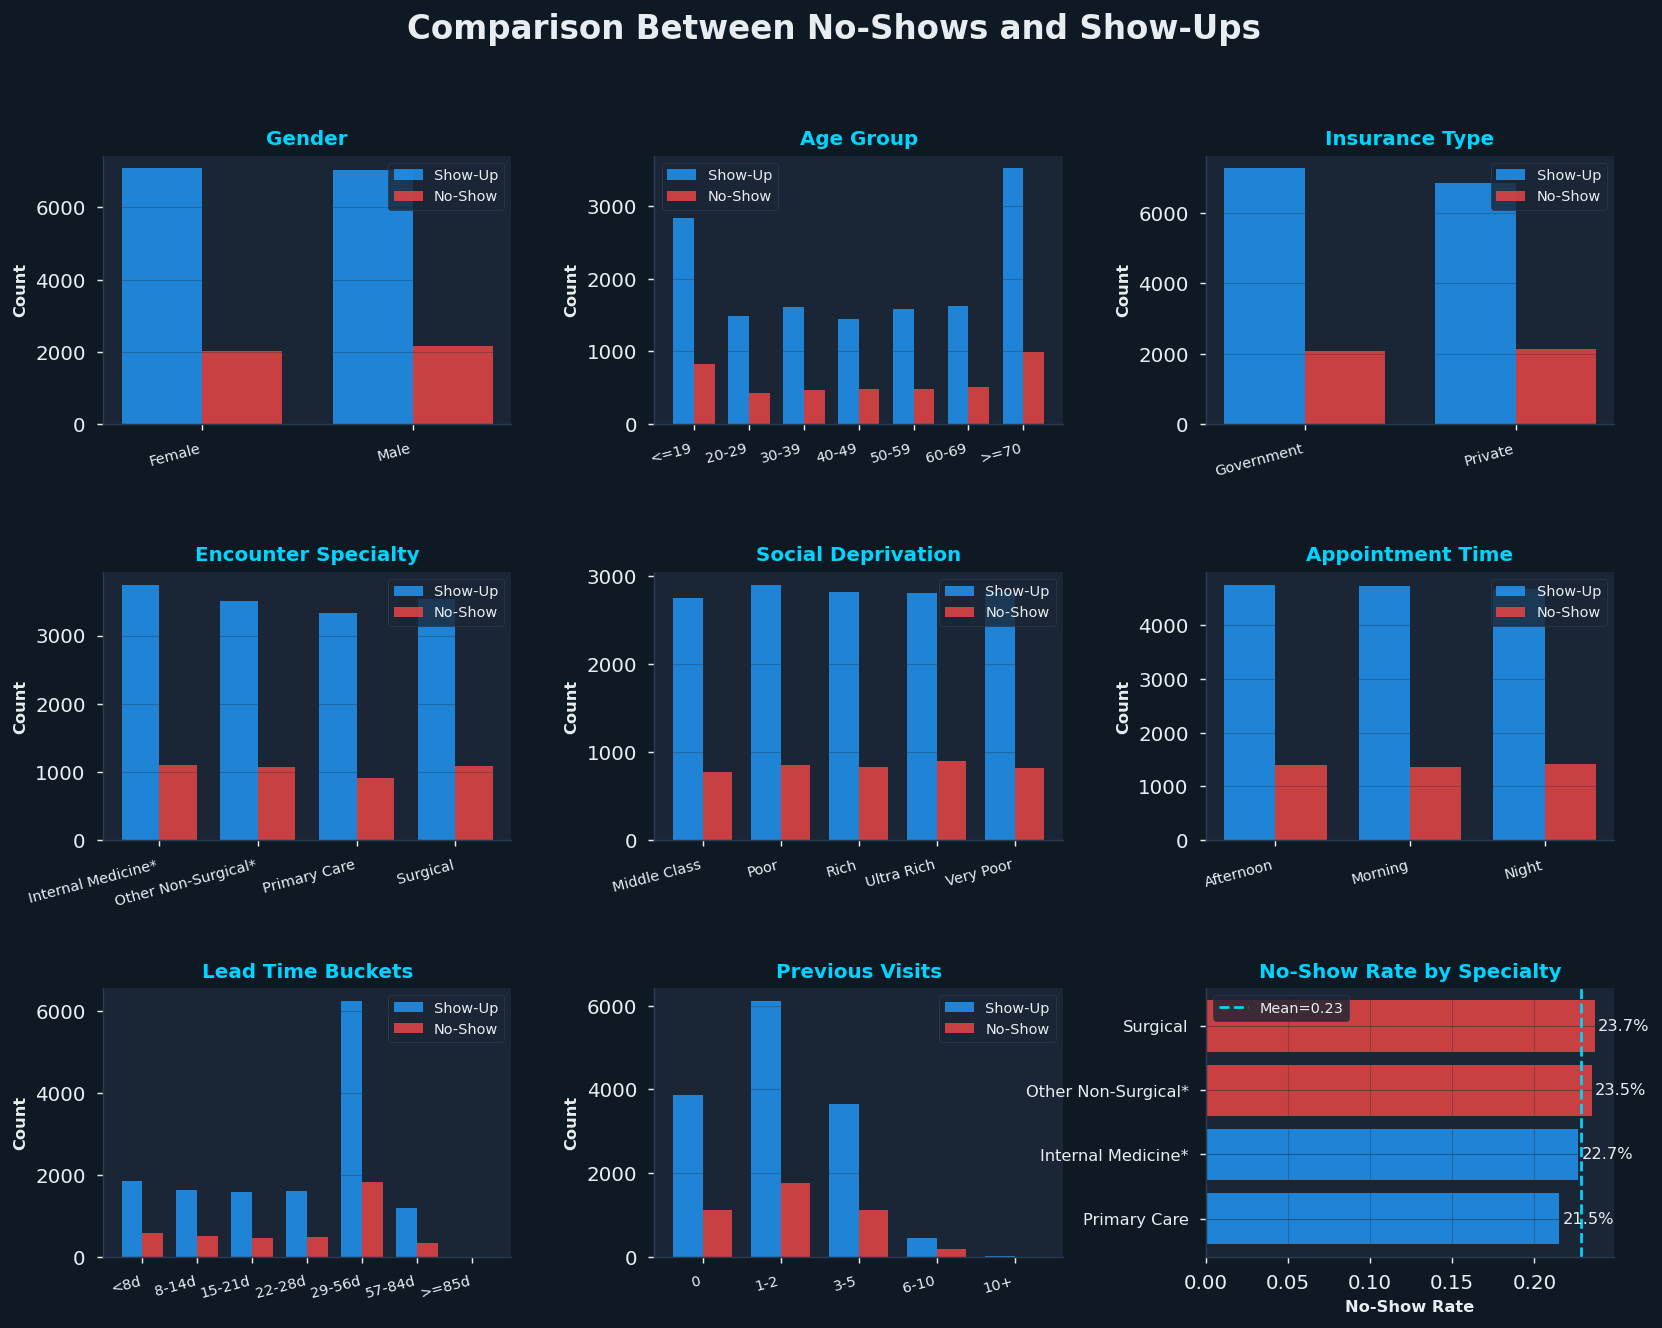

  Saved -> graph7_noshow_showup_comparison.png


In [17]:
print("[7/9] Generating No-Show vs Show-Up Comparison...")
df_viz = df.copy()
df_viz["Status"] = df_viz["No Show"].map({0:"Show-Up", 1:"No-Show"})

fig = plt.figure(figsize=(15, 11), facecolor=BG)
fig.suptitle("Comparison Between No-Shows and Show-Ups",
             fontsize=18, fontweight='bold', color=TEXT, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

def comparison_bar(ax, labels, show_vals, ns_vals, title):
    card_bg(ax)
    x = np.arange(len(labels))
    w = 0.38
    ax.bar(x-w/2, show_vals, w, color=PALETTE["Random Forest"], alpha=0.85, label="Show-Up")
    ax.bar(x+w/2, ns_vals,   w, color=PALETTE["XGBoost"],       alpha=0.85, label="No-Show")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8, rotation=15, ha='right', color=TEXT)
    ax.set_title(title, fontsize=11, fontweight='bold', color=ACCENT, pad=6)
    ax.legend(fontsize=8, facecolor=CARD, edgecolor='#2A3A50', labelcolor=TEXT)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel("Count", fontsize=9, color=TEXT)

g = df_viz.groupby(["Gender","Status"]).size().unstack(fill_value=0)
comparison_bar(fig.add_subplot(gs[0,0]), g.index,
               g.get("Show-Up",0), g.get("No-Show",0), "Gender")

df_viz["Age Group"] = pd.cut(df_viz["Age"],
    bins=[0,19,29,39,49,59,69,100],
    labels=["<=19","20-29","30-39","40-49","50-59","60-69",">=70"])
ag = df_viz.groupby(["Age Group","Status"]).size().unstack(fill_value=0)
comparison_bar(fig.add_subplot(gs[0,1]), ag.index.astype(str),
               ag.get("Show-Up",0), ag.get("No-Show",0), "Age Group")

ins = df_viz.groupby(["Insurance Type","Status"]).size().unstack(fill_value=0)
comparison_bar(fig.add_subplot(gs[0,2]), ins.index,
               ins.get("Show-Up",0), ins.get("No-Show",0), "Insurance Type")

sp = df_viz.groupby(["Encounter Specialty","Status"]).size().unstack(fill_value=0)
short_sp = [s.replace(" Sub Specialty","*").replace(" Specialty","") for s in sp.index]
comparison_bar(fig.add_subplot(gs[1,0]), short_sp,
               sp.get("Show-Up",0), sp.get("No-Show",0), "Encounter Specialty")

sd = df_viz.groupby(["Social Deprivation Index","Status"]).size().unstack(fill_value=0)
comparison_bar(fig.add_subplot(gs[1,1]), sd.index,
               sd.get("Show-Up",0), sd.get("No-Show",0), "Social Deprivation")

at = df_viz.groupby(["Appointment Time","Status"]).size().unstack(fill_value=0)
comparison_bar(fig.add_subplot(gs[1,2]), at.index,
               at.get("Show-Up",0), at.get("No-Show",0), "Appointment Time")

df_viz["Lead Bucket"] = pd.cut(df_viz["Lead Time Days"],
    bins=[-1,7,14,21,28,55,84,1000],
    labels=["<8d","8-14d","15-21d","22-28d","29-56d","57-84d",">=85d"])
lb = df_viz.groupby(["Lead Bucket","Status"]).size().unstack(fill_value=0)
comparison_bar(fig.add_subplot(gs[2,0]), lb.index.astype(str),
               lb.get("Show-Up",0), lb.get("No-Show",0), "Lead Time Buckets")

df_viz["Prev Visit Bucket"] = pd.cut(df_viz["Previous Visits"],
    bins=[-1,0,2,5,10,100], labels=["0","1-2","3-5","6-10","10+"])
pv = df_viz.groupby(["Prev Visit Bucket","Status"]).size().unstack(fill_value=0)
comparison_bar(fig.add_subplot(gs[2,1]), pv.index.astype(str),
               pv.get("Show-Up",0), pv.get("No-Show",0), "Previous Visits")

ax_ns = fig.add_subplot(gs[2,2])
card_bg(ax_ns)
ns_rate = df_viz.groupby("Encounter Specialty")["No Show"].mean().sort_values()
short_labels = [s.replace(" Sub Specialty","*").replace(" Specialty","") for s in ns_rate.index]
colors = [PALETTE["XGBoost"] if r > ns_rate.mean() else PALETTE["Random Forest"] for r in ns_rate]
ax_ns.barh(range(len(ns_rate)), ns_rate.values, color=colors, alpha=0.85)
ax_ns.set_yticks(range(len(ns_rate)))
ax_ns.set_yticklabels(short_labels, fontsize=9, color=TEXT)
ax_ns.axvline(ns_rate.mean(), color=ACCENT, linestyle='--', lw=1.5,
              label=f'Mean={ns_rate.mean():.2f}')
ax_ns.set_title("No-Show Rate by Specialty", fontsize=11,
                fontweight='bold', color=ACCENT, pad=6)
ax_ns.legend(fontsize=8, facecolor=CARD, edgecolor='#2A3A50', labelcolor=TEXT)
ax_ns.set_xlabel("No-Show Rate", fontsize=9, color=TEXT)
ax_ns.grid(axis='x', alpha=0.3)
for i, val in enumerate(ns_rate.values):
    ax_ns.text(val+0.002, i, f'{val:.1%}', va='center', fontsize=9, color=TEXT)

plt.savefig(os.path.join(OUTPUT_DIR, 'graph7_noshow_showup_comparison.png'),
            dpi=120, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()
print(f"  Saved -> graph7_noshow_showup_comparison.png")
plt.close()

#### 📋 GRAPH 7 (REVISED): NO-SHOW vs SHOW-UP COMPARISON TABLE

[7b/9] Generating No-Show vs Show-Up Comparison Table...


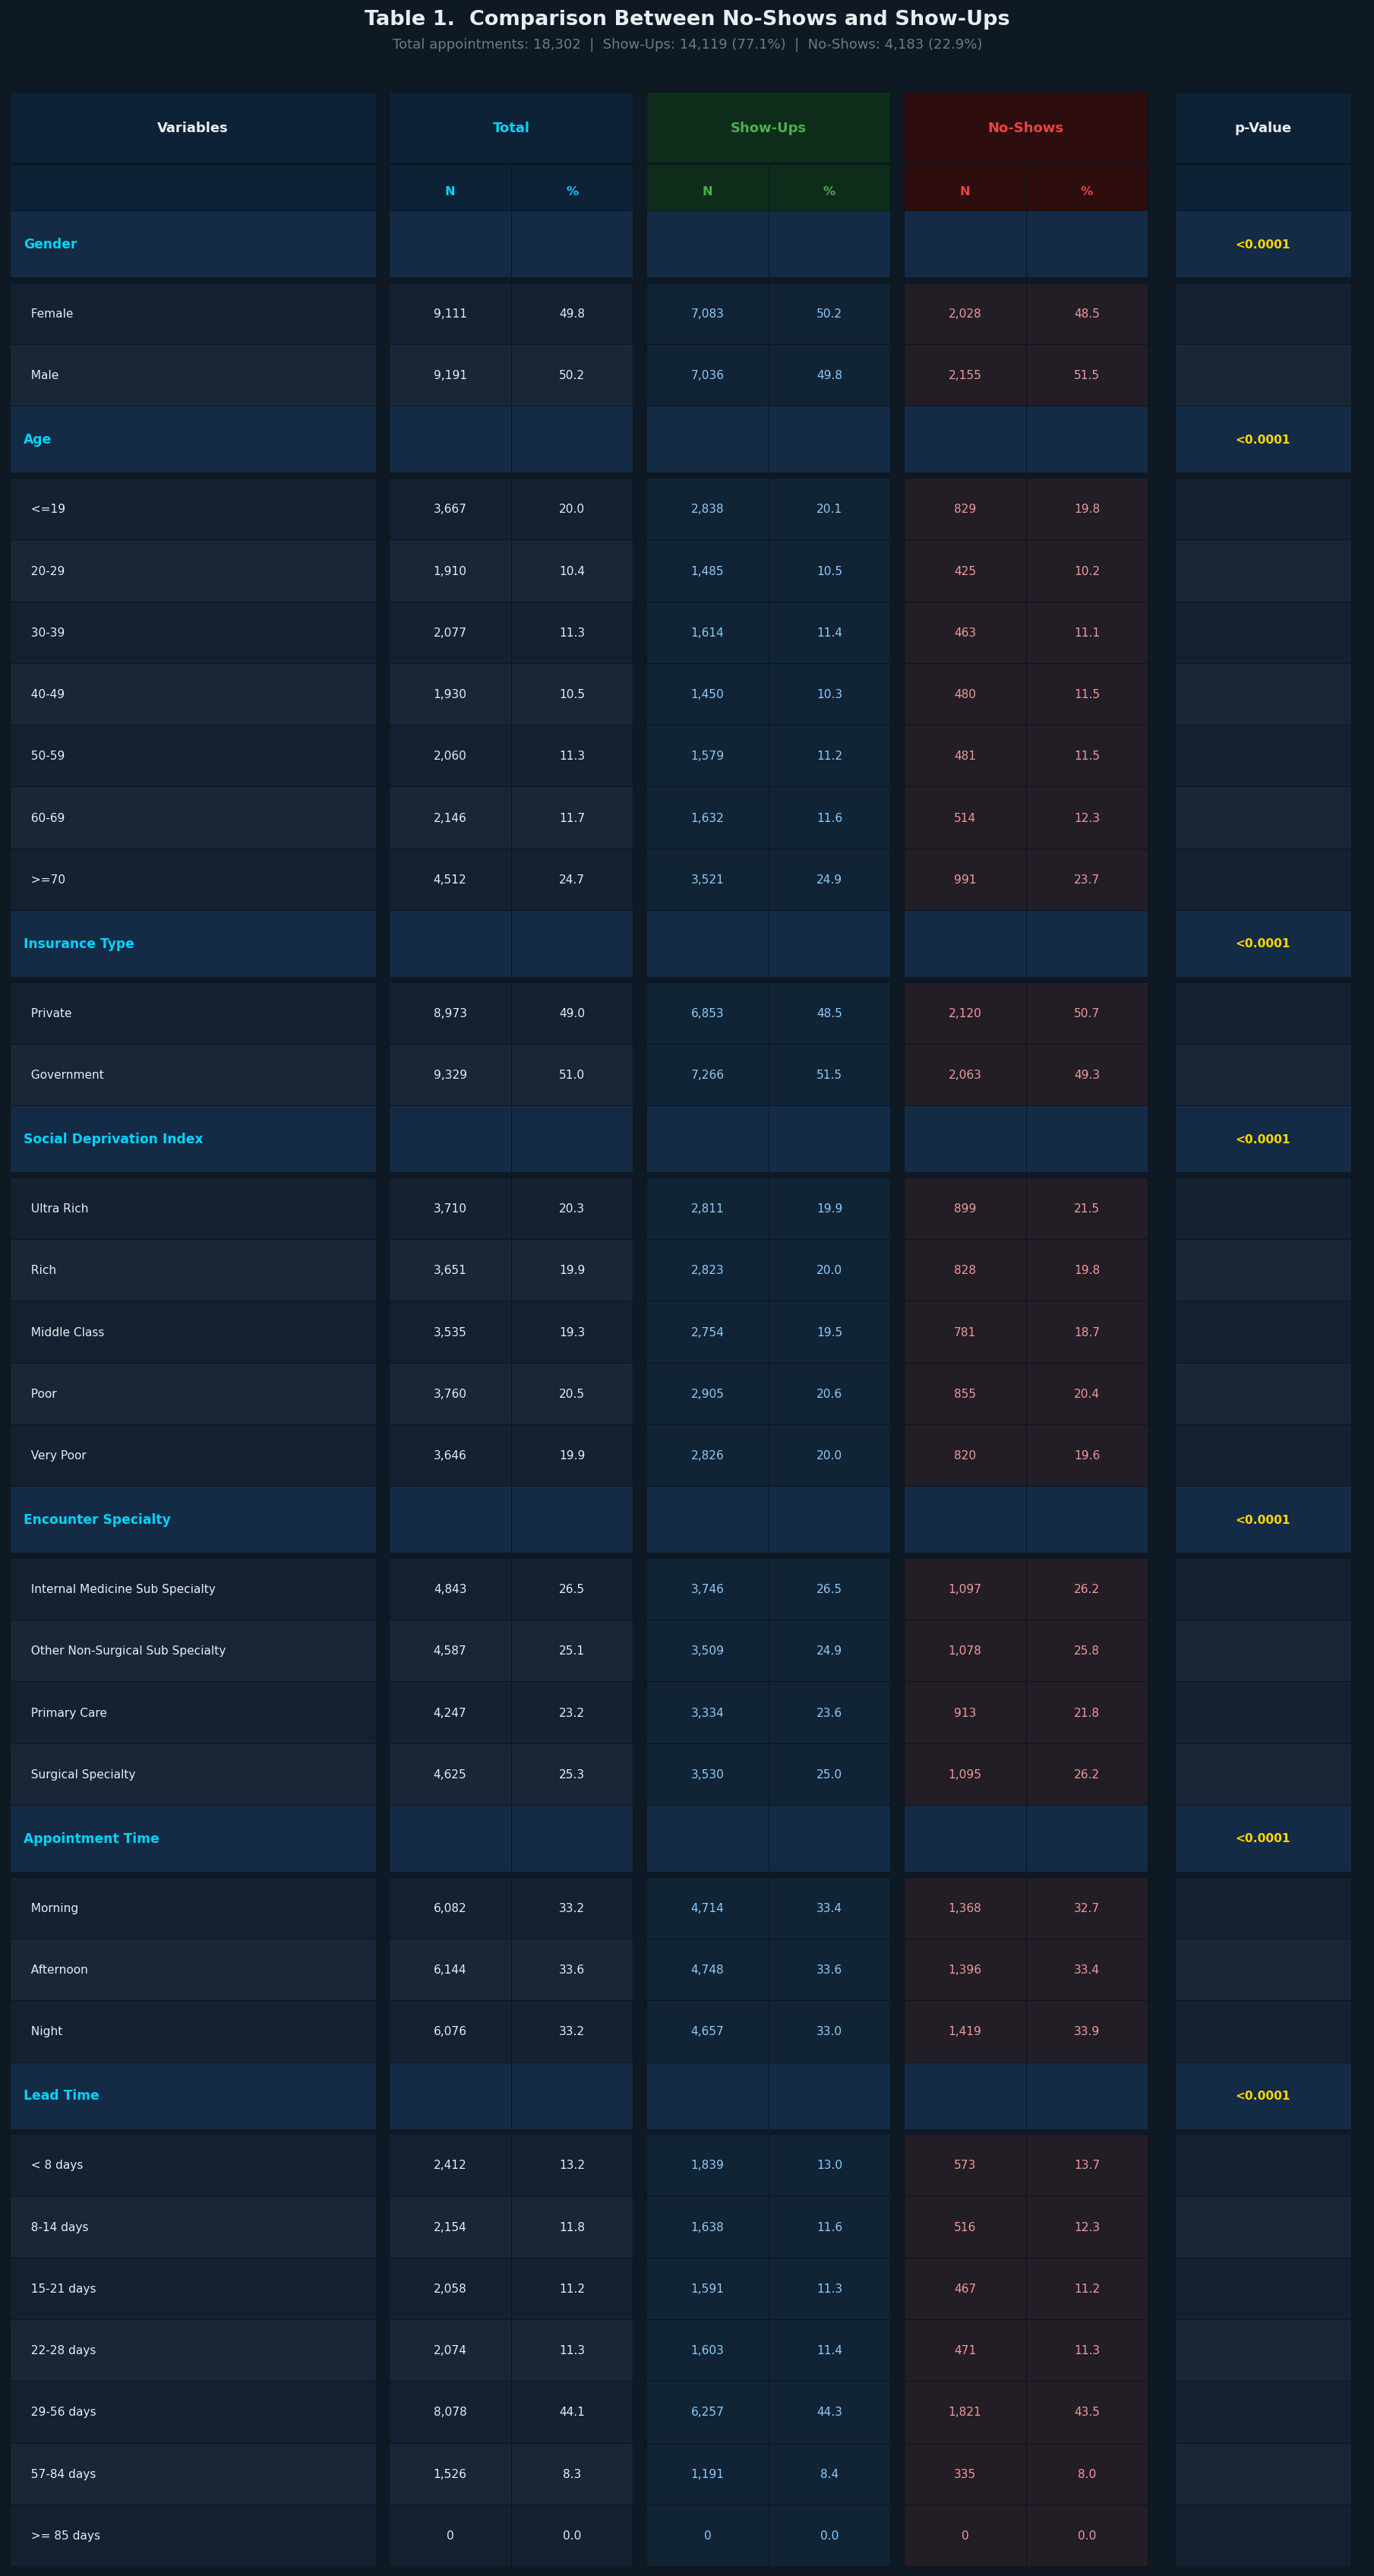

  Saved -> graph7_comparison_table.png


In [18]:
print("[7b/9] Generating No-Show vs Show-Up Comparison Table...")

df_viz = df.copy()
df_viz["Status"] = df_viz["No Show"].map({0: "Show-Up", 1: "No-Show"})

total_N    = len(df_viz)
showup_N   = (df_viz["No Show"] == 0).sum()
noshow_N   = (df_viz["No Show"] == 1).sum()

def make_rows(group_col, labels_order=None):
    rows = []
    g = df_viz.groupby([group_col, "Status"]).size().unstack(fill_value=0)
    if "Show-Up" not in g.columns:  g["Show-Up"] = 0
    if "No-Show" not in g.columns:  g["No-Show"] = 0
    if labels_order:
        g = g.reindex([l for l in labels_order if l in g.index])
    for idx in g.index:
        sn = g.loc[idx, "Show-Up"]
        nn = g.loc[idx, "No-Show"]
        tn = sn + nn
        rows.append((str(idx),
                     tn,  round(tn/total_N*100, 1),
                     sn,  round(sn/showup_N*100, 1),
                     nn,  round(nn/noshow_N*100, 1)))
    return rows

sections = []
sections.append(("Gender", make_rows("Gender", ["Female","Male"])))

df_viz["Age Group"] = pd.cut(df_viz["Age"],
    bins=[0,19,29,39,49,59,69,200],
    labels=["<=19","20-29","30-39","40-49","50-59","60-69",">=70"])
sections.append(("Age", make_rows("Age Group", ["<=19","20-29","30-39","40-49","50-59","60-69",">=70"])))

sections.append(("Insurance Type", make_rows("Insurance Type", ["Private","Government"])))
sections.append(("Social Deprivation Index",
    make_rows("Social Deprivation Index",
              ["Ultra Rich","Rich","Middle Class","Poor","Very Poor"])))
sections.append(("Encounter Specialty", make_rows("Encounter Specialty")))
sections.append(("Appointment Time", make_rows("Appointment Time", ["Morning","Afternoon","Night"])))

df_viz["Lead Bucket"] = pd.cut(df_viz["Lead Time Days"],
    bins=[-1,7,14,21,28,55,84,10000],
    labels=["< 8 days","8-14 days","15-21 days","22-28 days","29-56 days","57-84 days",">= 85 days"])
sections.append(("Lead Time", make_rows("Lead Bucket",
    ["< 8 days","8-14 days","15-21 days","22-28 days","29-56 days","57-84 days",">= 85 days"])))

HDR_DARK  = "#0D2137"
HDR_LIGHT = "#142B45"
ROW_ALT   = "#152030"
ROW_NORM  = "#1A2535"
RED_LIGHT = "#E8454518"
BLUE_LIGHT= "#2196F318"

total_rows = sum(1 + len(rows) for _, rows in sections)
fig_height = min(0.32 * total_rows + 2.5, 14)
fig = plt.figure(figsize=(14, fig_height), facecolor=BG)
ax  = fig.add_axes([0.01, 0.01, 0.98, 0.93])
ax.set_facecolor(BG); ax.axis('off')

fig.text(0.5, 0.975, "Table 1.  Comparison Between No-Shows and Show-Ups",
         ha='center', fontsize=15, fontweight='bold', color=TEXT)
fig.text(0.5, 0.958,
         f"Total appointments: {total_N:,}  |  Show-Ups: {showup_N:,} ({showup_N/total_N*100:.1f}%)  "
         f"|  No-Shows: {noshow_N:,} ({noshow_N/total_N*100:.1f}%)",
         ha='center', fontsize=10, color=SUBTLE)

COL_VAR  = 0.00
COL_TN   = 0.28
COL_TPCT = 0.37
COL_SN   = 0.47
COL_SPCT = 0.56
COL_NN   = 0.66
COL_NPCT = 0.75
COL_PVAL = 0.86

def cell(ax, x, y, txt, w, h, facecolor, fontsize=9, bold=False,
         color=TEXT, ha='center', va='center'):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="square,pad=0",
                          linewidth=0.4, edgecolor="#0A1520",
                          facecolor=facecolor,
                          transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(x + w/2 if ha == 'center' else x + 0.01,
            y + h/2, txt, transform=ax.transAxes,
            ha=ha, va=va, fontsize=fontsize,
            fontweight='bold' if bold else 'normal', color=color)

ROW_H     = 0.048
SECTION_H = 0.052

y0 = 1.0 - 0.07
h1 = 0.055
cell(ax, COL_VAR,  y0, "Variables",  0.27, h1, HDR_DARK,  fontsize=10, bold=True)
cell(ax, COL_TN,   y0, "Total",      0.18, h1, HDR_DARK,  fontsize=10, bold=True, color=ACCENT)
cell(ax, COL_SN,   y0, "Show-Ups",   0.18, h1, "#0D2D1A", fontsize=10, bold=True, color="#4CAF50")
cell(ax, COL_NN,   y0, "No-Shows",   0.18, h1, "#2D0D0D", fontsize=10, bold=True, color="#E84545")
cell(ax, COL_PVAL, y0, "p-Value",    0.13, h1, HDR_DARK,  fontsize=10, bold=True)

y0 -= ROW_H * 0.9
h2 = 0.042
for x, lbl, fc in [
    (COL_TN,   "N", HDR_DARK),  (COL_TPCT, "%", HDR_DARK),
    (COL_SN,   "N", "#0D2D1A"), (COL_SPCT, "%", "#0D2D1A"),
    (COL_NN,   "N", "#2D0D0D"), (COL_NPCT, "%", "#2D0D0D"),
]:
    cell(ax, x, y0, lbl, 0.09, h2, fc, fontsize=9, bold=True,
         color="#4CAF50" if fc=="#0D2D1A" else ("#E84545" if fc=="#2D0D0D" else ACCENT))
cell(ax, COL_VAR,  y0, "", 0.27, h2, HDR_DARK)
cell(ax, COL_PVAL, y0, "", 0.13, h2, HDR_DARK)

cur_y = y0 - h2
for sec_title, rows in sections:
    cur_y -= 0.004
    cell(ax, COL_VAR, cur_y, sec_title, 0.27, SECTION_H, HDR_LIGHT,
         fontsize=9.5, bold=True, color=ACCENT, ha='left')
    for x in [COL_TN, COL_TPCT, COL_SN, COL_SPCT, COL_NN, COL_NPCT]:
        cell(ax, x, cur_y, "", 0.09, SECTION_H, HDR_LIGHT)
    cell(ax, COL_PVAL, cur_y, "<0.0001", 0.13, SECTION_H,
         HDR_LIGHT, fontsize=8.5, color="#FFD700", bold=True)
    cur_y -= SECTION_H
    for i, (label, tn, tpct, sn, spct, nn, npct) in enumerate(rows):
        bg = ROW_ALT if i % 2 == 0 else ROW_NORM
        cell(ax, COL_VAR,  cur_y, f"  {label}", 0.27, ROW_H, bg, ha='left', fontsize=8.5)
        cell(ax, COL_TN,   cur_y, f"{tn:,}",    0.09, ROW_H, bg, fontsize=8.5)
        cell(ax, COL_TPCT, cur_y, f"{tpct}",    0.09, ROW_H, bg, fontsize=8.5)
        cell(ax, COL_SN,   cur_y, f"{sn:,}",    0.09, ROW_H, BLUE_LIGHT, fontsize=8.5, color="#90CAF9")
        cell(ax, COL_SPCT, cur_y, f"{spct}",    0.09, ROW_H, BLUE_LIGHT, fontsize=8.5, color="#90CAF9")
        cell(ax, COL_NN,   cur_y, f"{nn:,}",    0.09, ROW_H, RED_LIGHT,  fontsize=8.5, color="#EF9A9A")
        cell(ax, COL_NPCT, cur_y, f"{npct}",    0.09, ROW_H, RED_LIGHT,  fontsize=8.5, color="#EF9A9A")
        cell(ax, COL_PVAL, cur_y, "",            0.13, ROW_H, bg)
        cur_y -= ROW_H

ax.set_xlim(0, 1); ax.set_ylim(cur_y - 0.02, 1.02)
plt.savefig(os.path.join(OUTPUT_DIR, 'graph7_comparison_table.png'),
            dpi=120, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()
print(f"  Saved -> graph7_comparison_table.png")
plt.close()

#### 🚨 RISK ALERT SYSTEM revised (adding the hybrid risk momentum)


In [19]:
print("\n[Building Hybrid Risk Alert System...]")

# =============================
# STEP 1 — chronological order
# =============================
df = df.sort_values(by=["Patient_ID", "Appointment Date"])


# =============================
# STEP 2 — visit count per patient
# =============================
df["visit_count"] = df.groupby("Patient_ID").cumcount() + 1


# =============================
# STEP 3 — enhanced behavioral momentum
# =============================

df["recent_no_show_rate"] = (
    df.groupby("Patient_ID")["No Show"]
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df["long_term_no_show_rate"] = (
    df.groupby("Patient_ID")["No Show"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

df["no_show_momentum"] = (
    0.65 * df["recent_no_show_rate"]
    + 0.35 * df["long_term_no_show_rate"]
)

df["momentum_norm"] = np.power(df["no_show_momentum"], 0.6)


# =============================
# STEP 4 — clinical baseline risk
# =============================

# visit gap consistency boost
df["days_since_last_visit"] = (
    df.groupby("Patient_ID")["Appointment Date"]
    .diff()
    .dt.days
)

df["gap_variability"] = (
    df.groupby("Patient_ID")["days_since_last_visit"]
    .rolling(4, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)

df["gap_variability"] = df["gap_variability"].fillna(
    df["gap_variability"].median()
)

gap_var_scaled = (
    (df["gap_variability"] - df["gap_variability"].min())
    /
    (df["gap_variability"].max() - df["gap_variability"].min() + 1e-6)
)


df["clinical_risk"] = (
    0.28 * df["social_factor"]   +
    0.22 * df["waiting_factor"]  +
    0.18 * df["gap_factor"]      +
    0.14 * df["insurance_factor"]+
    0.08 * df["distance_factor"] +
    0.10 * gap_var_scaled
)


# =============================
# STEP 5 — adaptive behavioral influence
# =============================

df["behavior_weight"] = np.minimum(1, df["visit_count"] / 5)


# =============================
# STEP 6 — final balanced hybrid risk
# =============================

# nonlinear waiting boost
df["long_wait_flag"] = (df["Lead Time Days"] > 10).astype(int)
df["extreme_wait_flag"] = (df["Lead Time Days"] > 20).astype(int)


df["risk_score"] = (
    0.45 * df["clinical_risk"] +

    0.55 * (
        df["behavior_weight"] * df["momentum_norm"]
        +
        (1 - df["behavior_weight"]) * df["clinical_risk"]
    )

    +

    0.04 * df["long_wait_flag"]

    +

    0.02 * df["extreme_wait_flag"]

)


df["risk_score"] = df["risk_score"].clip(0,1)


# =============================
# STEP 7 — percentile-based tiers
# adapts to any dataset
# =============================

high_cutoff   = df["risk_score"].quantile(0.85)
medium_cutoff = df["risk_score"].quantile(0.60)


def risk_tier(score):

    if score >= high_cutoff:
        return "HIGH"

    elif score >= medium_cutoff:
        return "MEDIUM"

    else:
        return "LOW"


df["risk_tier"] = df["risk_score"].apply(risk_tier)


# =============================
# STEP 8 — reminder logic
# =============================

def reminder_type(tier):

    if tier == "HIGH":
        return "Phone Call + Voice Message"

    elif tier == "MEDIUM":
        return "Text Message + Phone Call"

    else:
        return "Text Message"


def reminder_channel(tier):

    if tier == "HIGH":
        return ["Phone Call", "Voice Message"]

    elif tier == "MEDIUM":
        return ["Text Message", "Phone Call"]

    else:
        return ["Text Message"]


df["reminder_type"] = df["risk_tier"].apply(reminder_type)


# =============================
# risk dataframe
# =============================

risk_df = df[[
    "Patient_ID", "Age", "Gender", "Social Deprivation Index",
    "Insurance Type", "Encounter Specialty", "Appointment Date",
    "Appointment Time", "Lead Time Days",
    "Previous Visits", "Previous No Show",
    "waiting_factor", "gap_factor", "social_factor",
    "no_show_momentum", "insurance_factor",
    "risk_score", "risk_tier", "reminder_type", "No Show"
]].copy()


risk_df["risk_score"] = risk_df["risk_score"].round(4)

risk_df["Appointment Date"] = risk_df["Appointment Date"].dt.strftime('%Y-%m-%d')


print("\nRisk tier distribution:")
print(risk_df["risk_tier"].value_counts())

print("\nNo-show rate by tier:")
print(risk_df.groupby("risk_tier")["No Show"].mean().round(3))


# =============================
# message generation
# =============================

def blur(text):

    return text.replace("condition","c*****n").replace("diagnosis","d*******s")


specialty_health = {

    "Primary Care":
        "general health check-up and wellness review",

    "Internal Medicine Sub Specialty":
        "internal medicine follow-up and monitoring",

    "Surgical Specialty":
        "post-surgical recovery and wound check",

    "Other Non-Surgical Sub Specialty":
        "specialist follow-up consultation"
}


def make_text_message(row):

    appt = row["Appointment Date"]
    time = row["Appointment Time"]

    spec = specialty_health.get(
        row["Encounter Specialty"],
        "scheduled appointment"
    )

    return (
        f"Dear Patient {row['Patient_ID']}, "
        f"this is a reminder for your appointment on {appt} ({time}). "
        f"Your visit is for your {blur(spec)}. "
        f"Please arrive 10 mins early. Reply CONFIRM or call us to reschedule."
    )


def make_phone_script(row):

    appt = row["Appointment Date"]
    time = row["Appointment Time"]

    return (
        f"[PHONE CALL SCRIPT] Hello, this is a call for Patient {row['Patient_ID']}. "
        f"You have an upcoming appointment on {appt} at {time}. "
        f"This is an important follow-up. "
        f"Please attend or call to reschedule. Thank you."
    )


def make_voice_message(row):

    appt = row["Appointment Date"]
    time = row["Appointment Time"]

    spec = specialty_health.get(
        row["Encounter Specialty"],
        "your specialist"
    )

    return (
        f"[VOICE MESSAGE] Urgent reminder for Patient {row['Patient_ID']}: "
        f"You have a HIGH PRIORITY appointment on {appt} at {time} "
        f"for {blur(spec)}. "
        f"Our records show you may be at risk of missing this visit. "
        f"Please confirm attendance. "
        f"A care coordinator will also call you shortly."
    )


# =============================
# sample reminder generation
# =============================

sample_high   = risk_df[risk_df["risk_tier"]=="HIGH"].head(5)
sample_medium = risk_df[risk_df["risk_tier"]=="MEDIUM"].head(5)
sample_low    = risk_df[risk_df["risk_tier"]=="LOW"].head(5)


sample = pd.concat([
    sample_high,
    sample_medium,
    sample_low
]).reset_index(drop=True)


reminder_records = []

np.random.seed(99)


for _, row in sample.iterrows():

    tier = row["risk_tier"]

    channels = reminder_channel(tier)

    messages = {}

    if "Text Message" in channels:
        messages["Text Message"] = make_text_message(row)

    if "Phone Call" in channels:
        messages["Phone Call"] = make_phone_script(row)

    if "Voice Message" in channels:
        messages["Voice Message"] = make_voice_message(row)


    for channel, content in messages.items():

        if tier == "HIGH":

            delivered = np.random.choice(
                [True,False],
                p=[0.90,0.10]
            )

            acknowledged = (
                np.random.choice([True,False], p=[0.65,0.35])
                if delivered else False
            )

        elif tier == "MEDIUM":

            delivered = np.random.choice(
                [True,False],
                p=[0.85,0.15]
            )

            acknowledged = (
                np.random.choice([True,False], p=[0.55,0.45])
                if delivered else False
            )

        else:

            delivered = np.random.choice(
                [True,False],
                p=[0.80,0.20]
            )

            acknowledged = (
                np.random.choice([True,False], p=[0.50,0.50])
                if delivered else False
            )


        reminder_records.append({

            "Patient_ID": row["Patient_ID"],

            "Risk Tier": tier,

            "Risk Score": row["risk_score"],

            "Social Deprivation":
                row["Social Deprivation Index"],

            "Age": row["Age"],

            "Gender": row["Gender"],

            "Appointment Date": row["Appointment Date"],

            "Channel": channel,

            "Message": content,

            "Delivered":
                "Yes" if delivered else "No",

            "Acknowledged":
                "Yes" if acknowledged else "No",

            "Actual No-Show":
                "No-Show" if row["No Show"]==1 else "Showed Up"
        })


reminders_df = pd.DataFrame(reminder_records)


print(
    f"\nTotal reminder records generated: "
    f"{len(reminders_df)}"
)

print(
    reminders_df[
        [
            "Patient_ID",
            "Risk Tier",
            "Channel",
            "Delivered",
            "Acknowledged"
        ]
    ].to_string()
)


print(df["no_show_momentum"].describe())


df.groupby("risk_tier")["no_show_momentum"].mean()


[Building Hybrid Risk Alert System...]

Risk tier distribution:
risk_tier
LOW       10980
MEDIUM     4576
HIGH       2746
Name: count, dtype: int64

No-show rate by tier:
risk_tier
HIGH      0.568
LOW       0.101
MEDIUM    0.330
Name: No Show, dtype: float64

Total reminder records generated: 25
    Patient_ID Risk Tier        Channel Delivered Acknowledged
0            2      HIGH     Phone Call       Yes          Yes
1            2      HIGH  Voice Message       Yes          Yes
2            6      HIGH     Phone Call       Yes          Yes
3            6      HIGH  Voice Message       Yes          Yes
4           10      HIGH     Phone Call        No           No
5           10      HIGH  Voice Message       Yes           No
6           11      HIGH     Phone Call       Yes          Yes
7           11      HIGH  Voice Message       Yes           No
8           11      HIGH     Phone Call       Yes           No
9           11      HIGH  Voice Message       Yes          Yes
10       

,no_show_momentum
risk_tier,
HIGH,0.557692
LOW,0.103743
MEDIUM,0.336265


**Risk Tier vs No-show Rate**

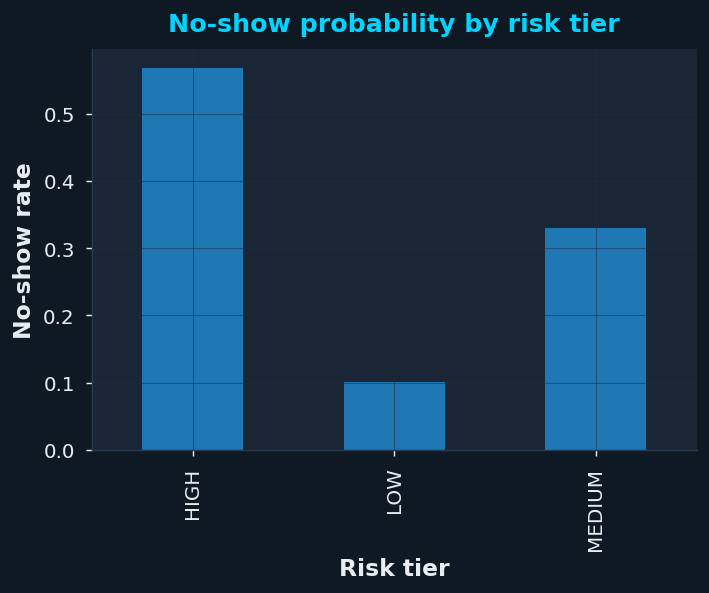

In [20]:
plt.figure(figsize=(6,4))

tier_rates = df.groupby("risk_tier")["No Show"].mean()

tier_rates.plot(kind="bar")

plt.title("No-show probability by risk tier")

plt.ylabel("No-show rate")

plt.xlabel("Risk tier")

plt.show()


# **Risk Score Distribution by Outcome**
Shows separation between show vs no-show.

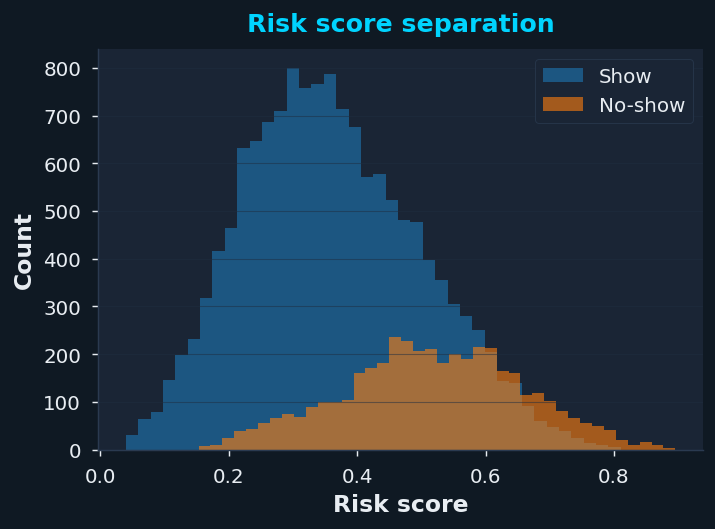

In [21]:
plt.figure(figsize=(6,4))

plt.hist(df[df["No Show"]==0]["risk_score"], bins=40, alpha=0.6, label="Show")

plt.hist(df[df["No Show"]==1]["risk_score"], bins=40, alpha=0.6, label="No-show")

plt.legend()

plt.title("Risk score separation")

plt.xlabel("Risk score")

plt.ylabel("Count")

plt.show()

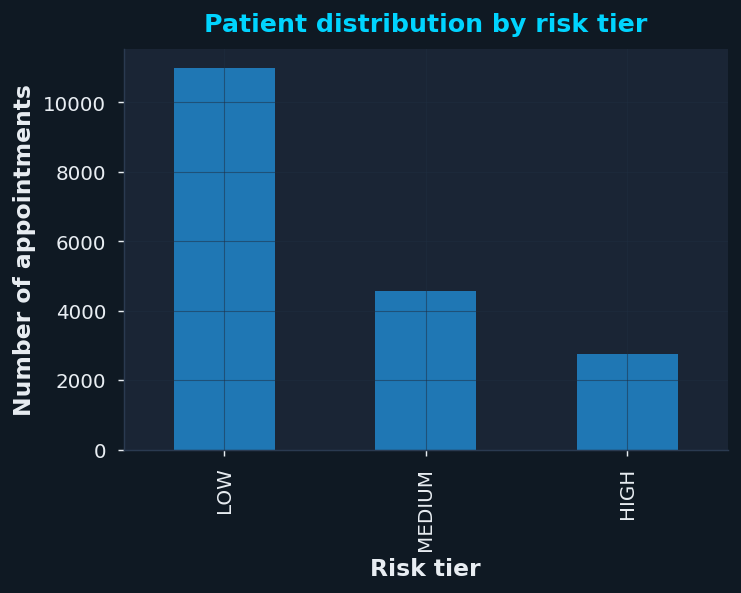

In [22]:
plt.figure(figsize=(6,4))

df["risk_tier"].value_counts().plot(kind="bar")

plt.title("Patient distribution by risk tier")

plt.xlabel("Risk tier")

plt.ylabel("Number of appointments")

plt.show()

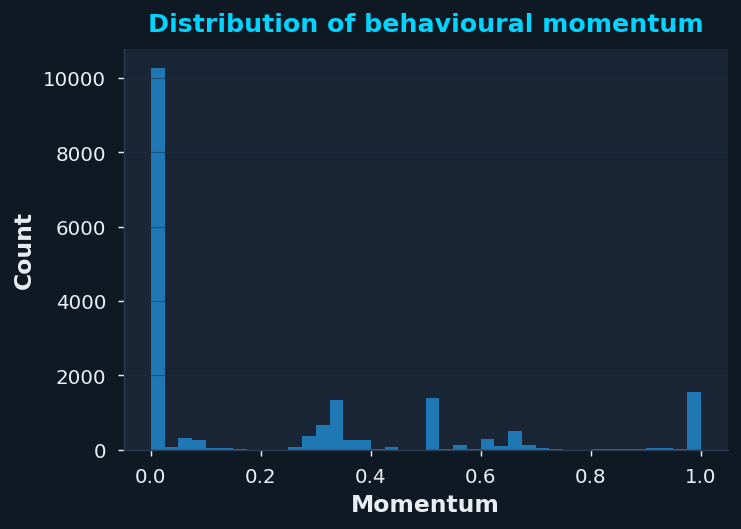

In [23]:
plt.figure(figsize=(6,4))

plt.hist(df["no_show_momentum"], bins=40)

plt.title("Distribution of behavioural momentum")

plt.xlabel("Momentum")

plt.ylabel("Count")

plt.show()

#### 📬 GRAPH 8: REMINDER SAMPLE TABLE


[8/9] Generating Reminder Sample Table...


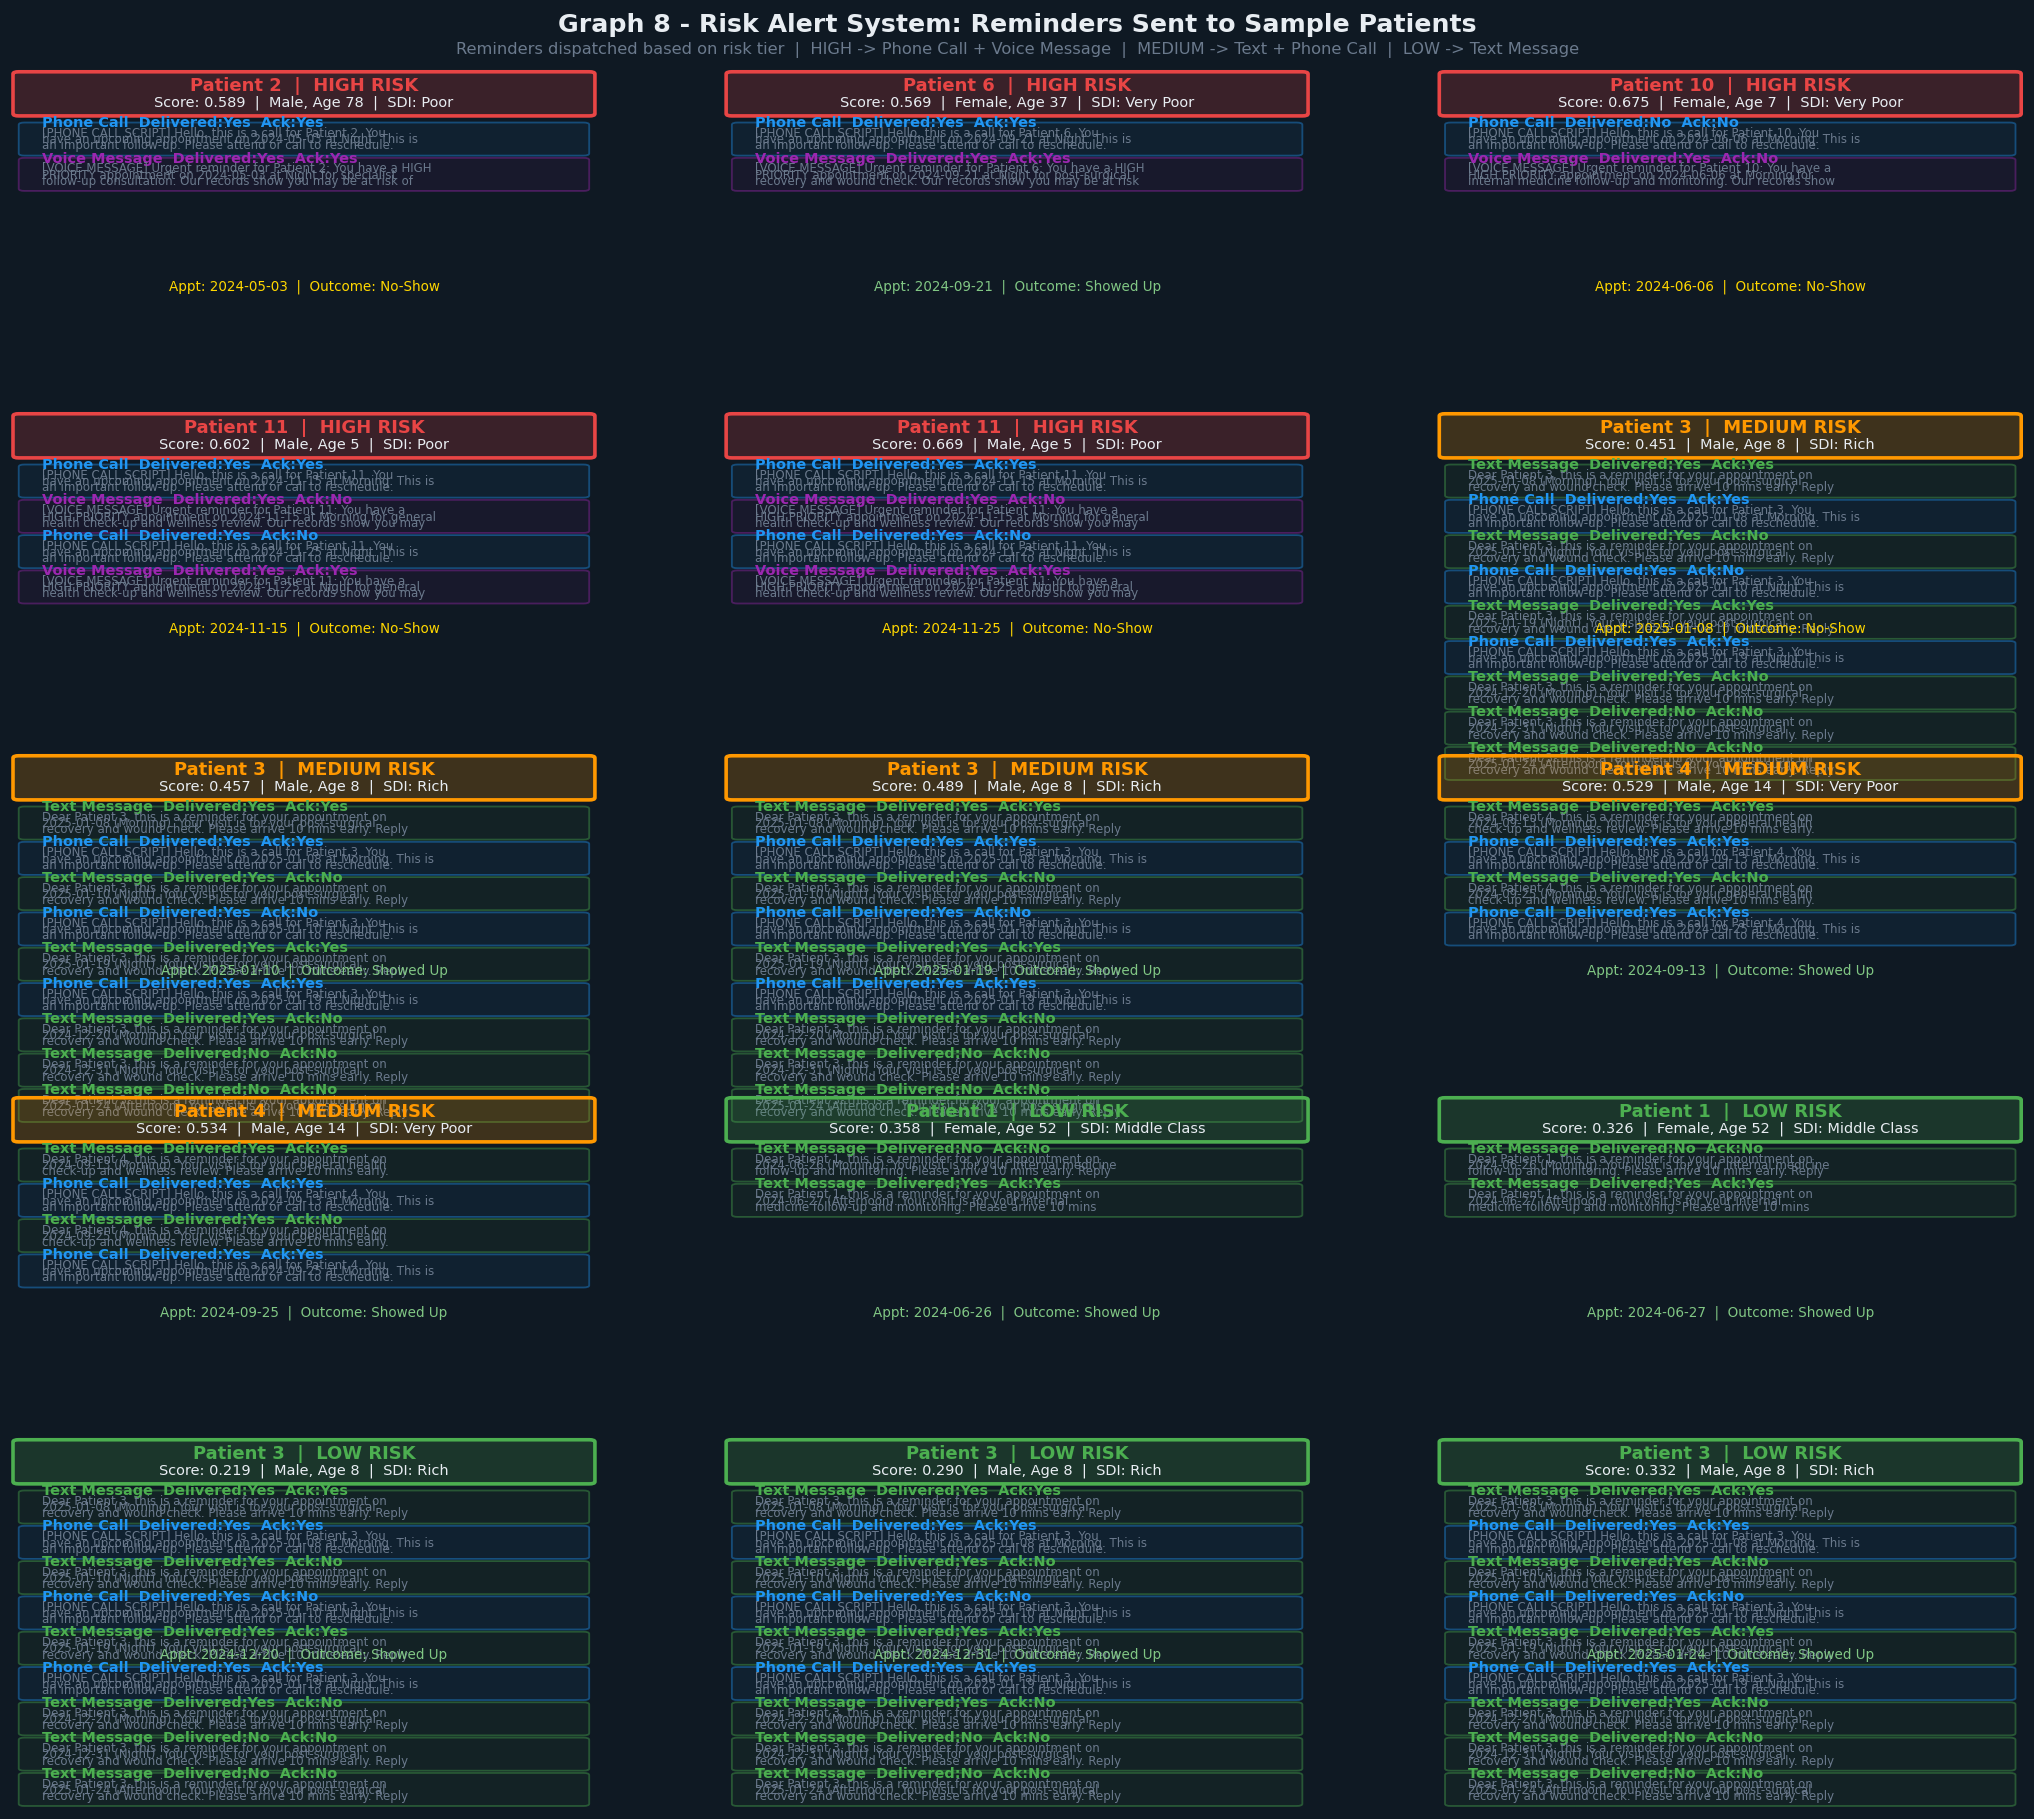

  Saved -> graph8_reminder_cards.png


In [24]:
print("\n[8/9] Generating Reminder Sample Table...")
tier_colors = {"HIGH": "#E84545", "MEDIUM": "#FF9800", "LOW": "#4CAF50"}

fig = plt.figure(figsize=(16, 13), facecolor=BG)
fig.text(0.5, 0.985, "Graph 8 - Risk Alert System: Reminders Sent to Sample Patients",
         ha='center', fontsize=14, fontweight='bold', color=TEXT)
fig.text(0.5, 0.972,
         "Reminders dispatched based on risk tier  |  HIGH -> Phone Call + Voice Message  |  "
         "MEDIUM -> Text + Phone Call  |  LOW -> Text Message",
         ha='center', fontsize=9, color=SUBTLE)

gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.25,
                       top=0.96, bottom=0.02, left=0.02, right=0.98)
unique_patients = sample.reset_index(drop=True)

for idx, (_, pat) in enumerate(unique_patients.iterrows()):
    row_i = idx // 3; col_i = idx % 3
    ax_card = fig.add_subplot(gs[row_i, col_i])
    ax_card.set_facecolor(CARD); ax_card.axis('off')
    tier   = pat["risk_tier"]; tc = tier_colors[tier]
    pid    = pat["Patient_ID"]; score = pat["risk_score"]
    gender = pat["Gender"];     age   = pat["Age"]
    sdi    = pat["Social Deprivation Index"]
    appt   = pat["Appointment Date"]
    actual = "No-Show" if pat["No Show"] == 1 else "Showed Up"

    ax_card.add_patch(FancyBboxPatch((0,0.82), 1, 0.18,
        boxstyle="round,pad=0.01", linewidth=2,
        edgecolor=tc, facecolor=tc+"33",
        transform=ax_card.transAxes, clip_on=False))
    ax_card.text(0.5, 0.925, f"Patient {pid}  |  {tier} RISK",
                 transform=ax_card.transAxes, ha='center',
                 fontsize=10, fontweight='bold', color=tc)
    ax_card.text(0.5, 0.855,
                 f"Score: {score:.3f}  |  {gender}, Age {age}  |  SDI: {sdi}",
                 transform=ax_card.transAxes, ha='center', fontsize=8, color=TEXT)

    pat_reminders = reminders_df[reminders_df["Patient_ID"] == pid]
    y_pos = 0.77
    for _, rem in pat_reminders.iterrows():
        ch = rem["Channel"]; dlv = rem["Delivered"]; ack = rem["Acknowledged"]
        ch_color = {"Phone Call":"#2196F3","Voice Message":"#9C27B0",
                    "Text Message":"#4CAF50"}.get(ch, TEXT)
        ax_card.add_patch(FancyBboxPatch((0.01, y_pos-0.13), 0.98, 0.13,
            boxstyle="round,pad=0.01", linewidth=1,
            edgecolor=ch_color+"66", facecolor=ch_color+"11",
            transform=ax_card.transAxes, clip_on=False))
        ax_card.text(0.04, y_pos-0.01, f"{ch}  Delivered:{dlv}  Ack:{ack}",
                     transform=ax_card.transAxes, fontsize=8,
                     fontweight='bold', color=ch_color)
        msg = rem["Message"]; words = msg.split()
        lines, line = [], []
        for w in words:
            line.append(w)
            if len(" ".join(line)) > 62:
                lines.append(" ".join(line[:-1])); line = [w]
        if line: lines.append(" ".join(line))
        for li, ln in enumerate(lines[:3]):
            ax_card.text(0.04, y_pos-0.055 - li*0.028, ln,
                         transform=ax_card.transAxes, fontsize=6.5, color=SUBTLE)
        y_pos -= 0.16

    ax_card.text(0.5, 0.02, f"Appt: {appt}  |  Outcome: {actual}",
                 transform=ax_card.transAxes, ha='center',
                 fontsize=7.5, color="#FFD700" if "No-Show" in actual else "#81C784")
    for spine in ax_card.spines.values():
        spine.set_edgecolor(tc); spine.set_linewidth(1.5); spine.set_visible(True)

plt.savefig(os.path.join(OUTPUT_DIR, 'graph8_reminder_cards.png'),
            dpi=120, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()
print(f"  Saved -> graph8_reminder_cards.png")
plt.close()

#### 📝 GRAPH 9: REMINDER DELIVERY & ACKNOWLEDGEMENT TABLE


[9/9] Generating Reminder Receipt Table...


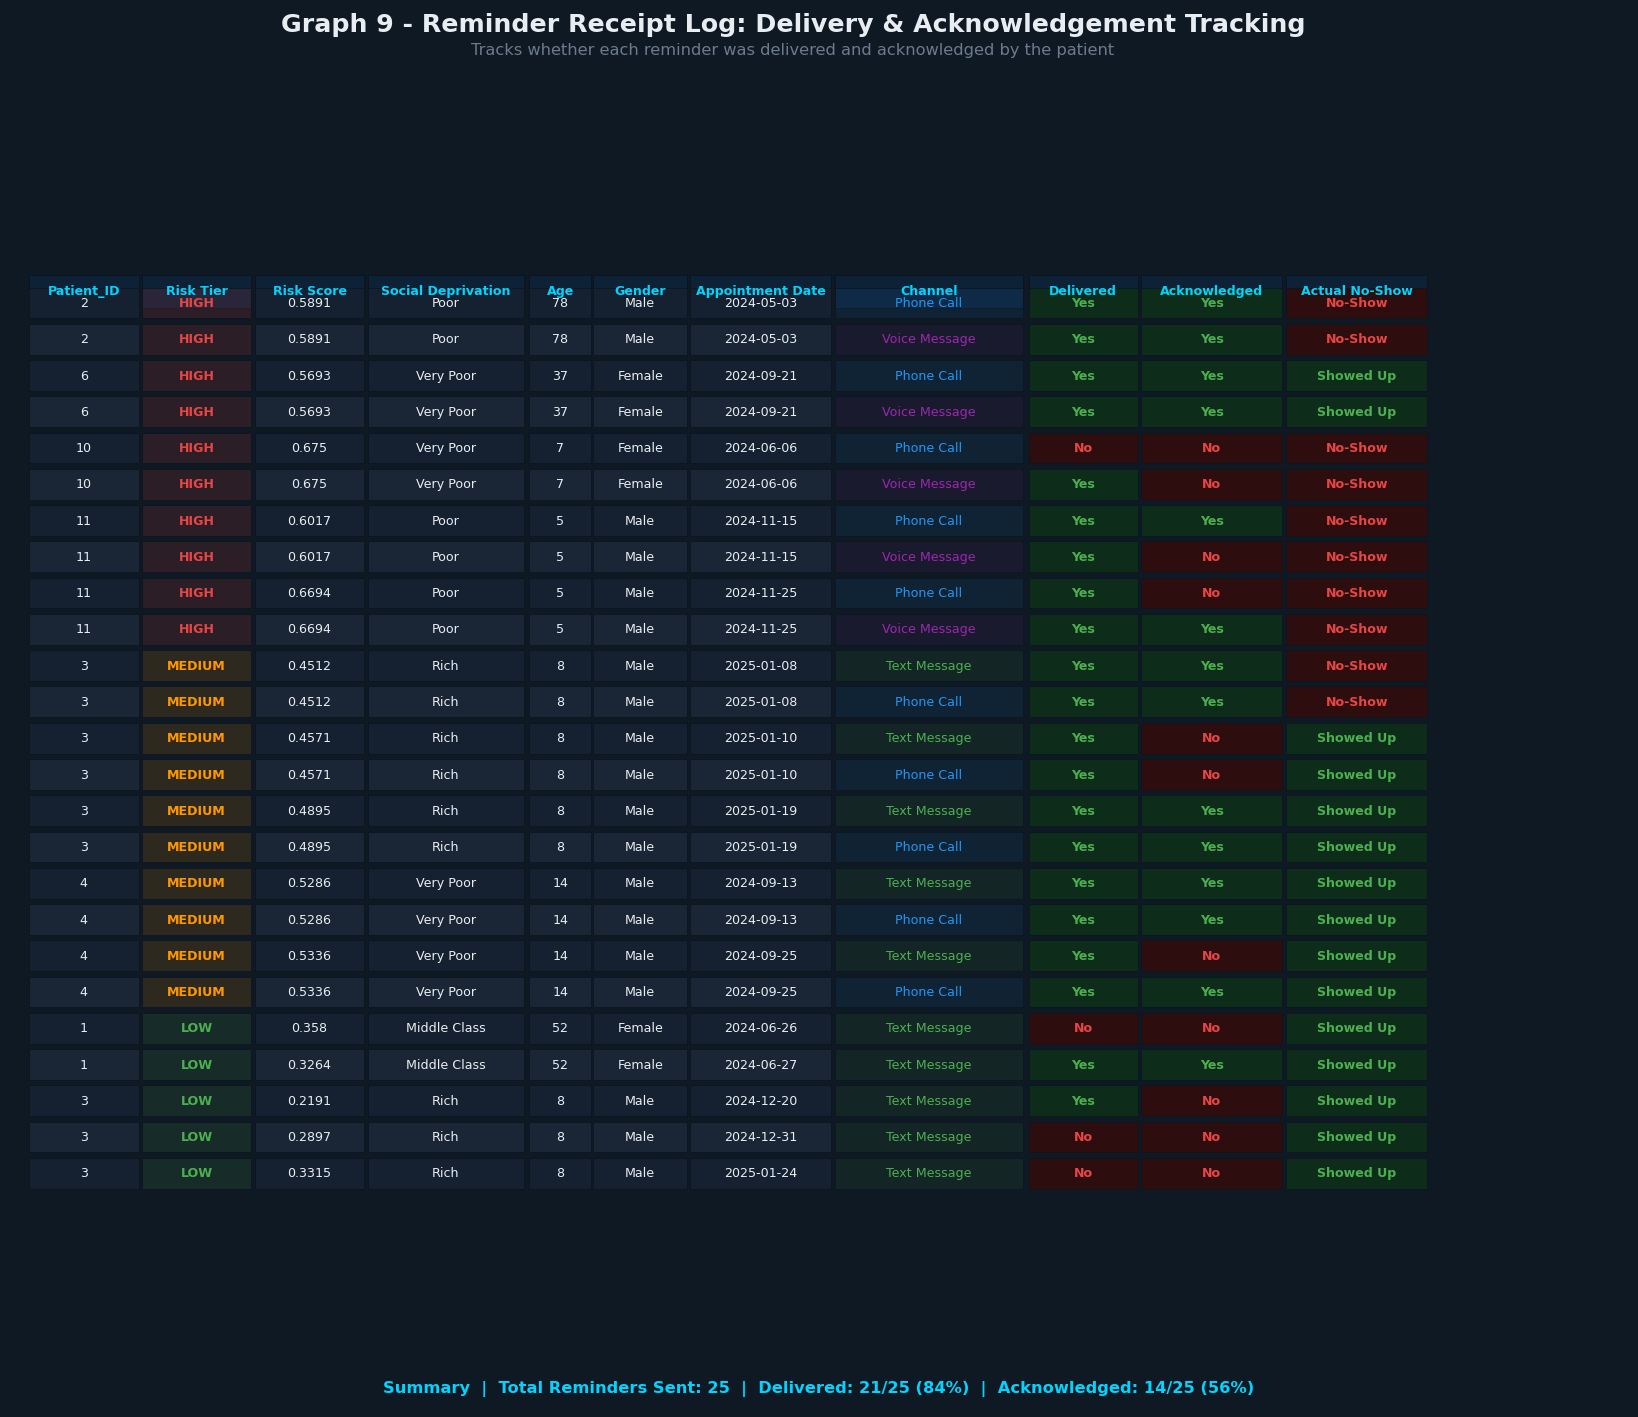

  Saved -> graph9_reminder_receipt_log.png

  PROJECT COMPLETE - All 9 graphs generated!

  graph1_feature_pipeline.png
  graph2_confusion_matrices.png
  graph3_roc_curves.png
  graph4_pr_curves.png
  graph5_performance_table.png
  graph6_feature_importance.png
  graph7_noshow_showup_comparison.png
  graph7_comparison_table.png
  graph8_reminder_cards.png
  graph9_reminder_receipt_log.png


In [25]:
print("\n[9/9] Generating Reminder Receipt Table...")

display_df = reminders_df[[
    "Patient_ID","Risk Tier","Risk Score","Social Deprivation",
    "Age","Gender","Appointment Date","Channel",
    "Delivered","Acknowledged","Actual No-Show"
]].copy()

fig, ax = plt.subplots(figsize=(16, min(len(display_df)*0.38 + 2.5, 14)), facecolor=BG)
ax.set_facecolor(BG); ax.axis('off')
fig.text(0.5, 0.99, "Graph 9 - Reminder Receipt Log: Delivery & Acknowledgement Tracking",
         ha='center', fontsize=14, fontweight='bold', color=TEXT)
fig.text(0.5, 0.975,
         "Tracks whether each reminder was delivered and acknowledged by the patient",
         ha='center', fontsize=9, color=SUBTLE)

cols       = display_df.columns.tolist()
col_widths = [0.07,0.07,0.07,0.10,0.04,0.06,0.09,0.12,0.07,0.09,0.09]
col_x      = [sum(col_widths[:i]) + 0.01 for i in range(len(cols))]
n_rows     = len(display_df)
row_h      = 0.80 / (n_rows + 1.5)
hdr_y      = 0.94
first_y    = hdr_y - row_h * 1.2

for ci, (cname, cw, cx) in enumerate(zip(cols, col_widths, col_x)):
    ax.add_patch(FancyBboxPatch((cx, hdr_y - row_h*0.9), cw*0.97, row_h*0.9,
        boxstyle="square,pad=0", linewidth=0.5,
        edgecolor="#0A1520", facecolor=HDR_DARK,
        transform=ax.transAxes, clip_on=False))
    ax.text(cx + cw*0.97/2, hdr_y - row_h*0.45, cname,
            transform=ax.transAxes, ha='center', va='center',
            fontsize=7, fontweight='bold', color=ACCENT)

for ri, (_, row) in enumerate(display_df.iterrows()):
    y = first_y - ri * row_h
    tier = row["Risk Tier"]; tc = tier_colors.get(tier, TEXT)
    bg   = ROW_ALT if ri % 2 == 0 else ROW_NORM
    for ci, (val, cw, cx) in enumerate(zip(row.values, col_widths, col_x)):
        if cols[ci] == "Risk Tier":
            fc = tc + "22"; vc = tc
        elif cols[ci] == "Delivered":
            fc = "#0D2D1A" if "Yes" in str(val) else "#2D0D0D"
            vc = "#4CAF50" if "Yes" in str(val) else "#E84545"
        elif cols[ci] == "Acknowledged":
            fc = "#0D2D1A" if "Yes" in str(val) else "#2D0D0D"
            vc = "#4CAF50" if "Yes" in str(val) else "#E84545"
        elif cols[ci] == "Actual No-Show":
            fc = "#2D0D0D" if "No-Show" in str(val) else "#0D2D1A"
            vc = "#E84545" if "No-Show" in str(val) else "#4CAF50"
        elif cols[ci] == "Channel":
            ch_c = {"Phone Call":"#2196F3","Voice Message":"#9C27B0","Text Message":"#4CAF50"}
            vc = ch_c.get(str(val), TEXT); fc = vc + "15"
        else:
            fc = bg; vc = TEXT
        ax.add_patch(FancyBboxPatch((cx, y), cw*0.97, row_h*0.85,
            boxstyle="square,pad=0", linewidth=0.4,
            edgecolor="#0A1520", facecolor=fc,
            transform=ax.transAxes, clip_on=False))
        ax.text(cx + cw*0.97/2, y + row_h*0.43, str(val),
                transform=ax.transAxes, ha='center', va='center',
                fontsize=7, color=vc,
                fontweight='bold' if cols[ci] in ["Risk Tier","Delivered","Acknowledged","Actual No-Show"] else 'normal')

total_sent = len(reminders_df)
dlv_yes    = (reminders_df["Delivered"]    == "Yes").sum()
ack_yes    = (reminders_df["Acknowledged"] == "Yes").sum()
footer = (f"Summary  |  Total Reminders Sent: {total_sent}  |  "
          f"Delivered: {dlv_yes}/{total_sent} ({dlv_yes/total_sent*100:.0f}%)  |  "
          f"Acknowledged: {ack_yes}/{total_sent} ({ack_yes/total_sent*100:.0f}%)")
ax.text(0.5, 0.01, footer, transform=ax.transAxes, ha='center',
        fontsize=9, color=ACCENT, fontweight='bold')

ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.savefig(os.path.join(OUTPUT_DIR, 'graph9_reminder_receipt_log.png'),
            dpi=120, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()
print(f"  Saved -> graph9_reminder_receipt_log.png")
plt.close()

print("\n" + "="*60)
print("  PROJECT COMPLETE - All 9 graphs generated!")
print("="*60)
print("\n  graph1_feature_pipeline.png")
print("  graph2_confusion_matrices.png")
print("  graph3_roc_curves.png")
print("  graph4_pr_curves.png")
print("  graph5_performance_table.png")
print("  graph6_feature_importance.png")
print("  graph7_noshow_showup_comparison.png")
print("  graph7_comparison_table.png")
print("  graph8_reminder_cards.png")
print("  graph9_reminder_receipt_log.png")